# CAMM Hackathon 12: Real-Time Drift Correction

In this challenge, the image is acquired line-by-line while the sample drifts. Your goal is to estimate that drift online and correct the image as the scan arrives.

## Task

Build a method that, for each newly acquired scan line:

- estimates the current drift
- updates the reconstructed image in real time
- produces a corrected final image

Keep the solution simple and fast enough to run during acquisition.

## What is provided

This notebook gives you:

- one STEM image to use as source data
- several synthetic drift models
- a simulator that corrupts the image line-by-line
- a streaming generator that mimics real-time acquisition

You only need to focus on the correction strategy.

## 1. Setup

In [ ]:
# Install dependencies (Colab / fresh environment)
!pip -q install SciFiReaders gdown


In [ ]:
from pathlib import Path

file_id = "16Oavm1j0gcGR2mPXWCAqLfVm1MSngy1Z"
filename = "1547 STEM 1.45 Mx HAADF 0001.emd"

if not Path(filename).exists():
    !gdown {file_id} -O "{filename}"
else:
    print(f"Using existing file: {filename}")


Using existing file: 1547 STEM 1.45 Mx HAADF 0001.emd


## 2. Imports

In [ ]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from SciFiReaders import EMDReader


## 3. Drift Models

These helper functions generate different drift trajectories. They are provided for testing and benchmarking.

In [ ]:
#@title drift models




def drift_constant_velocity(
    n_lines: int,
    vx: float = 0.02,
    vy: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Constant-velocity drift.

    Model:
        ux(t) = u0x + vx * t
        uy(t) = u0y + vy * t

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx, vy : float
        Drift velocity in pixels per unit time.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial drift offsets in pixels.

    Returns
    -------
    t : ndarray, shape (n_lines,)
        Time axis.
    ux, uy : ndarray, shape (n_lines,)
        Drift trajectory in pixels.
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + vx * t
    uy = u0y + vy * t
    return t, ux, uy


def drift_constant_velocity_random_walk(
    n_lines: int,
    vx0: float = 0.02,
    vy0: float = 0.0,
    sigma_ax: float = 0.002,
    sigma_ay: float = 0.002,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Constant-velocity model with random-walk velocity.

    State evolution:
        vx[t+1] = vx[t] + eps_x
        vy[t+1] = vy[t] + eps_y
        ux[t+1] = ux[t] + vx[t] * dt
        uy[t+1] = uy[t] + vy[t] * dt

    This is a very good default Kalman-style drift model.

    Parameters
    ----------
    n_lines : int
        Number of scan lines.
    vx0, vy0 : float
        Initial velocities in pixels per unit time.
    sigma_ax, sigma_ay : float
        Std of velocity perturbation per step.
    dt : float
        Time step per line.
    u0x, u0y : float
        Initial offsets.
    seed : int or None
        Random seed.

    Returns
    -------
    t, ux, uy : ndarray
        Time axis and drift trajectories.
    """
    rng = np.random.default_rng(seed)

    t = np.arange(n_lines, dtype=float) * dt
    ux = np.zeros(n_lines, dtype=float)
    uy = np.zeros(n_lines, dtype=float)
    vx = np.zeros(n_lines, dtype=float)
    vy = np.zeros(n_lines, dtype=float)

    ux[0], uy[0] = u0x, u0y
    vx[0], vy[0] = vx0, vy0

    for i in range(1, n_lines):
        vx[i] = vx[i - 1] + rng.normal(0.0, sigma_ax)
        vy[i] = vy[i - 1] + rng.normal(0.0, sigma_ay)

        ux[i] = ux[i - 1] + vx[i - 1] * dt
        uy[i] = uy[i - 1] + vy[i - 1] * dt

    return t, ux, uy


def drift_creep_log(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 20.0,
    tau_y: float = 20.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Logarithmic creep-like drift.

    Model:
        ux(t) = u0x + ax * log(1 + t / tau_x)
        uy(t) = u0y + ay * log(1 + t / tau_y)

    Useful as a simple AFM-like creep surrogate.

    Parameters
    ----------
    ax, ay : float
        Drift amplitudes in pixels.
    tau_x, tau_y : float
        Characteristic time scales.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.log1p(t / tau_x)
    uy = u0y + ay * np.log1p(t / tau_y)
    return t, ux, uy


def drift_creep_exponential(
    n_lines: int,
    ax: float = 2.0,
    ay: float = 0.5,
    tau_x: float = 30.0,
    tau_y: float = 30.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Exponential relaxation / creep model.

    Model:
        ux(t) = u0x + ax * (1 - exp(-t / tau_x))
        uy(t) = u0y + ay * (1 - exp(-t / tau_y))

    Good when drift is strongest at the beginning and saturates.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * (1.0 - np.exp(-t / tau_x))
    uy = u0y + ay * (1.0 - np.exp(-t / tau_y))
    return t, ux, uy


def drift_oscillatory(
    n_lines: int,
    ax: float = 0.5,
    ay: float = 0.2,
    freq_x: float = 0.02,
    freq_y: float = 0.03,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    dt: float = 1.0,
    u0x: float = 0.0,
    u0y: float = 0.0,
):
    """
    Oscillatory drift model.

    Model:
        ux(t) = u0x + ax * sin(2*pi*freq_x*t + phase_x)
        uy(t) = u0y + ay * sin(2*pi*freq_y*t + phase_y)

    Useful as a toy vibration / periodic instability component.

    Parameters
    ----------
    ax, ay : float
        Oscillation amplitudes in pixels.
    freq_x, freq_y : float
        Frequencies in cycles per unit time.

    Returns
    -------
    t, ux, uy : ndarray
    """
    t = np.arange(n_lines, dtype=float) * dt
    ux = u0x + ax * np.sin(2 * np.pi * freq_x * t + phase_x)
    uy = u0y + ay * np.sin(2 * np.pi * freq_y * t + phase_y)
    return t, ux, uy


def drift_composite(
    n_lines: int,
    dt: float = 1.0,
    linear_vx: float = 0.01,
    linear_vy: float = 0.0,
    creep_ax: float = 1.0,
    creep_ay: float = 0.3,
    creep_tau_x: float = 25.0,
    creep_tau_y: float = 25.0,
    osc_ax: float = 0.1,
    osc_ay: float = 0.05,
    osc_freq_x: float = 0.02,
    osc_freq_y: float = 0.015,
    phase_x: float = 0.0,
    phase_y: float = 0.0,
    noise_sigma_x: float = 0.02,
    noise_sigma_y: float = 0.02,
    u0x: float = 0.0,
    u0y: float = 0.0,
    seed: int | None = None,
):
    """
    Composite drift model:
    linear trend + creep + oscillation + small random noise.

    This is often the most realistic general-purpose simulator.

    Returns
    -------
    t, ux, uy : ndarray
    """
    rng = np.random.default_rng(seed)
    t = np.arange(n_lines, dtype=float) * dt

    linear_x = linear_vx * t
    linear_y = linear_vy * t

    creep_x = creep_ax * (1.0 - np.exp(-t / creep_tau_x))
    creep_y = creep_ay * (1.0 - np.exp(-t / creep_tau_y))

    osc_x = osc_ax * np.sin(2 * np.pi * osc_freq_x * t + phase_x)
    osc_y = osc_ay * np.sin(2 * np.pi * osc_freq_y * t + phase_y)

    noise_x = rng.normal(0.0, noise_sigma_x, size=n_lines)
    noise_y = rng.normal(0.0, noise_sigma_y, size=n_lines)

    ux = u0x + linear_x + creep_x + osc_x + noise_x
    uy = u0y + linear_y + creep_y + osc_y + noise_y

    return t, ux, uy

### Visualize example drift trajectories

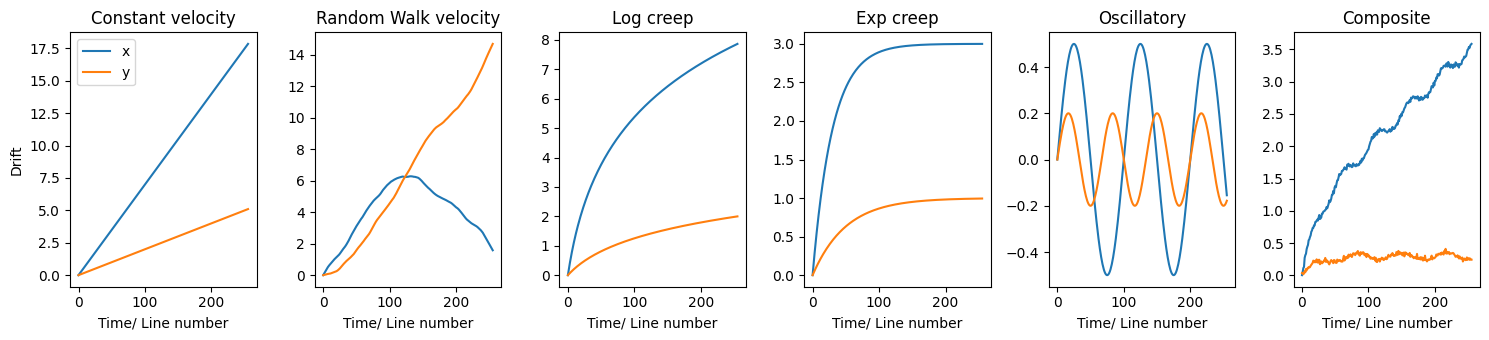

In [ ]:
import matplotlib.pyplot as plt

n_lines = 256

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5))

# --- 1. Constant velocity ---
t, ux1, uy1 = drift_constant_velocity(n_lines, vx=0.07, vy=0.02)
axes[0].plot(t, ux1, label='x')
axes[0].plot(t, uy1, label='y')
axes[0].legend()
axes[0].set_title("Constant velocity")

# --- 2. Random walk velocity ---
t, ux2, uy2 = drift_constant_velocity_random_walk(
    n_lines,
    vx0=0.07,
    vy0=0.01,
    sigma_ax=0.005,
    sigma_ay=0.005,
    seed=0
)
axes[1].plot(t, ux2, label='x')
axes[1].plot(t, uy2, label='y')
axes[1].set_title("Random Walk velocity")

# --- 3. Log creep ---
t, ux3, uy3 = drift_creep_log(n_lines, ax=3.0, ay=1.0, tau_x=20, tau_y=40)
axes[2].plot(t, ux3)
axes[2].plot(t, uy3)
axes[2].set_title("Log creep")

# --- 4. Exp creep ---
t, ux4, uy4 = drift_creep_exponential(n_lines, ax=3.0, ay=1.0, tau_x=30, tau_y=50)
axes[3].plot(t, ux4)
axes[3].plot(t, uy4)
axes[3].set_title("Exp creep")

# --- 5. Oscillatory ---
t, ux5, uy5 = drift_oscillatory(
    n_lines, ax=0.5, ay=0.2, freq_x=0.01, freq_y=0.015
)
axes[4].plot(t, ux5)
axes[4].plot(t, uy5)
axes[4].set_title("Oscillatory")

# --- 6. Composite ---
t, ux6, uy6 = drift_composite(n_lines, seed=2)
axes[5].plot(t, ux6)
axes[5].plot(t, uy6)
axes[5].set_title("Composite")

# --- formatting ---
for ax in axes:
    #ax.set_xticks([])   # cleaner
    #ax.set_yticks([])
    ax.set_xlabel("Time/ Line number")


#axes[0].set_xlabel("Time")
axes[0].set_ylabel("Drift")


fig.tight_layout()
plt.show()

## 4. Load the Source Image

In [ ]:
emd_path = Path("1547 STEM 1.45 Mx HAADF 0001.emd")
reader = EMDReader(str(emd_path))
data = reader.read()

haadf_data = data["Channel_000"][:]
print("Loaded image shape:", haadf_data.shape)


Loaded image shape: (2048, 2048)


## 5. Drift Simulator

This helper creates a corrupted scan from a clean image and returns the ground-truth drift used to generate it.

In [ ]:
import numpy as np
from dataclasses import dataclass
from typing import Callable, Any
from scipy.ndimage import map_coordinates


@dataclass
class DriftSimulationResult:
    cropped_reference: np.ndarray
    cropped_corrupted: np.ndarray
    t: np.ndarray
    ux: np.ndarray
    uy: np.ndarray
    model_name: str
    model_kwargs: dict[str, Any]
    crop_bbox: tuple[int, int, int, int]  # y0, y1, x0, x1


def simulate_scan_drift_cropped_output(
    image: np.ndarray,
    model: str | Callable[..., tuple[np.ndarray, np.ndarray, np.ndarray]],
    model_kwargs: dict | None = None,
    out_shape: tuple[int, int] | None = None,
    dt: float = 1.0,
    interpolation_order: int = 1,
    extra_margin: int = 2,
    drift_models: dict[str, Callable] | None = None,
):
    """
    Simulate line-by-line drift, but return only a central cropped output.
    Important: drifted sampling is performed from the FULL image, not from a pre-cropped image.

    Parameters
    ----------
    image : np.ndarray
        Input 2D image.
    model : str or callable
        Drift model name or callable returning (t, ux, uy).
    model_kwargs : dict or None
        Parameters for drift model.
    out_shape : tuple[int, int] or None
        Output cropped shape (H, W). If None, use the maximal safe central crop.
    dt : float
        Time step per line.
    interpolation_order : int
        Interpolation order for map_coordinates.
    extra_margin : int
        Extra safety pixels beyond max drift.
    drift_models : dict or None
        Optional registry of named drift models.

    Returns
    -------
    DriftSimulationResult
    """
    if image.ndim != 2:
        raise ValueError("image must be a 2D array")

    H, W = image.shape
    model_kwargs = {} if model_kwargs is None else dict(model_kwargs)

    if drift_models is None:
        drift_models = {
            "constant_velocity": drift_constant_velocity,
            "random_walk_velocity": drift_constant_velocity_random_walk,
            "creep_log": drift_creep_log,
            "creep_exponential": drift_creep_exponential,
            "oscillatory": drift_oscillatory,
            "composite": drift_composite,
        }

    # resolve model
    if isinstance(model, str):
        if model not in drift_models:
            raise ValueError(f"Unknown model '{model}'. Available: {list(drift_models)}")
        model_fn = drift_models[model]
        model_name = model
    else:
        model_fn = model
        model_name = getattr(model, "__name__", "custom_model")

    # determine number of lines
    if out_shape is not None:
        out_h, out_w = out_shape
        model_kwargs["n_lines"] = out_h
    else:
        model_kwargs.setdefault("n_lines", H)

    model_kwargs.setdefault("dt", dt)

    # generate drift
    t, ux, uy = model_fn(**model_kwargs)
    ux = np.asarray(ux, dtype=float)
    uy = np.asarray(uy, dtype=float)

    if ux.shape != uy.shape:
        raise ValueError("ux and uy must have the same shape")

    n_lines = len(ux)

    # safe crop margins
    margin_x = int(np.ceil(np.max(np.abs(ux)))) + extra_margin
    margin_y = int(np.ceil(np.max(np.abs(uy)))) + extra_margin

    safe_h = H - 2 * margin_y
    safe_w = W - 2 * margin_x

    if safe_h <= 0 or safe_w <= 0:
        raise ValueError("Image too small for requested drift magnitude")

    if out_shape is None:
        out_h = min(n_lines, safe_h)
        out_w = safe_w
    else:
        out_h, out_w = out_shape
        if n_lines != out_h:
            raise ValueError(
                f"len(ux)={n_lines} must match out_shape[0]={out_h}"
            )
        if out_h > safe_h or out_w > safe_w:
            raise ValueError(
                f"Requested out_shape={out_shape} exceeds safe crop {(safe_h, safe_w)}"
            )

    # define central crop in the reference image
    y0 = (H - out_h) // 2
    x0 = (W - out_w) // 2
    y1 = y0 + out_h
    x1 = x0 + out_w

    cropped_reference = image[y0:y1, x0:x1]

    # simulate corrupted cropped output using FULL image coordinates
    cropped_corrupted = np.zeros((out_h, out_w), dtype=float)
    x_local = np.arange(out_w, dtype=float)

    for i in range(out_h):
        y_full = np.full(out_w, y0 + i + uy[i], dtype=float)
        x_full = x0 + x_local + ux[i]

        cropped_corrupted[i] = map_coordinates(
            image,
            [y_full, x_full],
            order=interpolation_order,
            mode="nearest",
        )

    return DriftSimulationResult(
        cropped_reference=cropped_reference,
        cropped_corrupted=cropped_corrupted,
        t=t[:out_h],
        ux=ux[:out_h],
        uy=uy[:out_h],
        model_name=model_name,
        model_kwargs=model_kwargs,
        crop_bbox=(y0, y1, x0, x1),
    )

## 6. Create a Sample Drifted Image

Use this synthetic example to develop and debug your method.

In [ ]:
result = simulate_scan_drift_cropped_output(
    image=haadf_data,
    model="random_walk_velocity",
    model_kwargs={
        "vx0": 0.13,
        "vy0": 0.17,
        "sigma_ax": 0.03,
        "sigma_ay": 0.03,
        "seed": 1,
    },
    out_shape=(256, 256),
    interpolation_order=1,
    extra_margin=3,
)

img_ref = result.cropped_reference
img_cor = result.cropped_corrupted
ux = result.ux
uy = result.uy


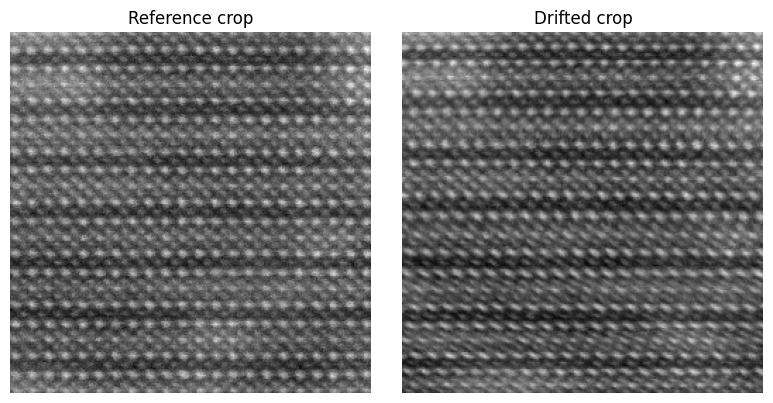

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_ref, cmap="gray")
axes[0].set_title("Reference crop")
axes[0].axis("off")

axes[1].imshow(img_cor, cmap="gray")
axes[1].set_title("Drifted crop")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 7. Streaming Interface

The function below yields the scan one line at a time, like a live acquisition stream.

In [ ]:
from typing import Callable, Any, Iterator

def corrupted_image_scan_stream(
    corrupted_image: np.ndarray,
    true_ux: np.ndarray | None = None,
    true_uy: np.ndarray | None = None,
) -> Iterator[dict]:
    """
    Yield scan progress line-by-line.

    Returns a dict containing:
    - current line index
    - current line
    - partial image acquired so far
    - optional true drift
    """
    if corrupted_image.ndim != 2:
        raise ValueError("corrupted_image must be a 2D array")

    H, W = corrupted_image.shape
    partial = np.full((H, W), np.nan, dtype=float)

    for i in range(H):
        partial[i] = corrupted_image[i]

        item = {
            "line_index": i,
            "line": corrupted_image[i].copy(),
            "partial_image": partial.copy(),
        }

        if true_ux is not None:
            item["ux_true"] = float(true_ux[i])
        if true_uy is not None:
            item["uy_true"] = float(true_uy[i])

        yield item

## 8. Your Code

Suggested outputs:

- corrected image
- estimated drift versus line index
- short note on your approach and assumptions

In [ ]:
#your code

## 9. Optional Demo

This cell visualizes how the corrupted image is revealed during acquisition.

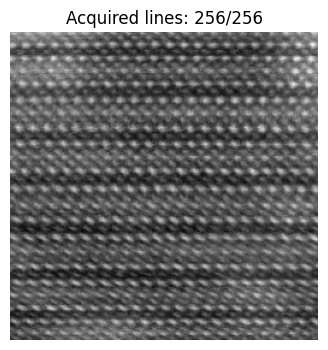

In [ ]:
stream = corrupted_image_scan_stream(img_cor)

for _ in range(len(img_cor)):
    frame = next(stream)
    clear_output(wait=True)
    plt.figure(figsize=(4, 4))
    plt.imshow(frame["partial_image"], cmap="gray")
    plt.title(f"Acquired lines: {frame['line_index'] + 1}/{len(img_cor)}")
    plt.axis("off")
    plt.show()
    time.sleep(0.05)


# try 1

In [ ]:
# ============================================================
# CELL 1: Imports & Professional Plot Styling
# ============================================================

import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.ndimage import map_coordinates, uniform_filter
from scipy.signal import correlate
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.85,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7f7f7',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.8,
    'image.cmap': 'inferno',
})

CMAP_IMG   = 'inferno'
CMAP_ERR   = 'hot'
COLOR_X    = '#2196F3'   # blue  – x-drift
COLOR_Y    = '#FF5722'   # orange – y-drift
COLOR_GOOD = '#4CAF50'   # green  – corrected
COLOR_BAD  = '#F44336'   # red    – corrupted

print("✓ Imports & style ready.")


✓ Imports & style ready.


In [ ]:
# ============================================================
# CELL 2: Core Estimation Utilities
# ============================================================

def ncc_shift_1d(ref_line, query_line, max_shift=50):
    """
    Estimate horizontal shift of query_line relative to ref_line
    via normalised cross-correlation.  Returns sub-pixel shift.
    """
    n = len(ref_line)
    def norm(x):
        mu, sig = x.mean(), x.std() + 1e-9
        return (x - mu) / sig

    corr  = correlate(norm(ref_line), norm(query_line), mode='full')
    lags  = np.arange(-(n - 1), n)
    ctr   = n - 1
    lo    = max(0,        ctr - max_shift)
    hi    = min(len(corr), ctr + max_shift + 1)
    c_win = corr[lo:hi]
    l_win = lags[lo:hi]

    pk = int(np.argmax(c_win))
    # sub-pixel parabolic refinement
    if 0 < pk < len(c_win) - 1:
        a, b_, c_ = c_win[pk-1], c_win[pk], c_win[pk+1]
        denom = a - 2*b_ + c_
        delta = 0.5*(a - c_) / (denom + 1e-12) if abs(denom) > 1e-12 else 0.0
        return float(l_win[pk]) + delta
    return float(l_win[pk])


def phase_corr_2d(patch1, patch2, max_shift=30):
    """
    2D phase correlation; returns (shift_x, shift_y).
    Hanning-windowed to suppress edge artifacts.
    """
    h, w = patch1.shape
    win  = np.outer(np.hanning(h), np.hanning(w))
    F1   = np.fft.fft2(patch1 * win)
    F2   = np.fft.fft2(patch2 * win)
    R    = F1 * np.conj(F2)
    R   /= (np.abs(R) + 1e-8)
    r    = np.fft.fftshift(np.real(np.fft.ifft2(R)))

    cy, cx = h // 2, w // 2
    mask   = np.zeros_like(r)
    y0, y1 = max(0, cy-max_shift), min(h, cy+max_shift+1)
    x0, x1 = max(0, cx-max_shift), min(w, cx+max_shift+1)
    mask[y0:y1, x0:x1] = r[y0:y1, x0:x1]

    pk = np.unravel_index(np.argmax(mask), mask.shape)
    return float(pk[1] - cx), float(pk[0] - cy)


def shift_line(line, dx, mode='nearest'):
    """Sub-pixel horizontal shift of a 1-D array.  Returns array shape (n,)."""
    n   = len(line)
    src = np.arange(n, dtype=float) - dx          # source coords
    return map_coordinates(line, [src], order=1, mode=mode)   # 1-D, no [0]



print("✓ Estimation utilities ready.")


✓ Estimation utilities ready.


In [ ]:
# ============================================================
# CELL 3: 4-State Kalman Filter  [ux, vx, uy, vy]
# ============================================================

class KalmanDriftFilter:
    """
    Constant-velocity Kalman filter for 2-D drift tracking.
    State:  x = [ux, vx, uy, vy]^T
    Obs:    z = [ux, uy]^T  (position only)
    """
    def __init__(self, dt=1.0,
                 sigma_pos=0.1,   # process noise – position
                 sigma_vel=0.03,  # process noise – velocity
                 sigma_meas_x=1.5,
                 sigma_meas_y=2.0):

        self.F = np.array([[1, dt, 0,  0],
                           [0,  1, 0,  0],
                           [0,  0, 1, dt],
                           [0,  0, 0,  1]], dtype=float)
        self.H = np.array([[1, 0, 0, 0],
                           [0, 0, 1, 0]], dtype=float)
        self.Q = np.diag([sigma_pos**2, sigma_vel**2,
                          sigma_pos**2, sigma_vel**2])
        self.R = np.diag([sigma_meas_x**2, sigma_meas_y**2])
        self.x = np.zeros(4)
        self.P = np.eye(4) * 5.0
        self._init = False

    # ---- public API -----------------------------------------------
    def initialise(self, ux0, uy0):
        self.x[:] = [ux0, 0.0, uy0, 0.0]
        self._init = True

    def step(self, z_ux, z_uy):
        """Predict + update; returns smoothed (ux, uy)."""
        if not self._init:
            self.initialise(z_ux, z_uy)
            return z_ux, z_uy
        # predict
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        # update
        z = np.array([z_ux, z_uy])
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return float(self.x[0]), float(self.x[2])

    def predict_only(self):
        """Pure prediction (no measurement)."""
        x_pred = self.F @ self.x
        return float(x_pred[0]), float(x_pred[2])


print("✓ Kalman filter ready.")


✓ Kalman filter ready.


In [ ]:
# ============================================================
# CELL 4: OnlineDriftCorrector
# ============================================================

class OnlineDriftCorrector:
    """
    Real-time drift corrector for line-by-line STEM acquisition.

    Per-line strategy
    -----------------
    X-drift  : 1-D NCC of current line vs. rolling x-corrected
               reference buffer  →  absolute x measurement.
    Y-drift  : block-level 2-D phase correlation every `block_y`
               lines between the x-corrected block and a reference
               block taken from the start of the scan.
    Smoothing: 4-state Kalman filter on (ux, uy) per line.

    Reconstruction (post-scan)
    --------------------------
    corrected[i, j] ≈ corrupted[i - uy_est[i], j - ux_est[i]]
    via bilinear map_coordinates (inverse warp).
    """

    def __init__(self, img_shape,
                 ref_window=20,
                 max_shift=60,
                 block_y=16,
                 kalman_kw=None):

        self.H, self.W    = img_shape
        self.ref_window   = ref_window
        self.max_shift    = max_shift
        self.block_y      = block_y

        kw = kalman_kw or {}
        self.kf = KalmanDriftFilter(
            sigma_pos   = kw.get('sp',   0.10),
            sigma_vel   = kw.get('sv',   0.03),
            sigma_meas_x= kw.get('smx',  1.5),
            sigma_meas_y= kw.get('smy',  2.0),
        )

        # Drift estimates
        self.ux_est  = np.zeros(self.H)
        self.uy_est  = np.zeros(self.H)
        self.ux_raw  = np.zeros(self.H)
        self.uy_raw  = np.zeros(self.H)

        # Internal buffers
        self._raw_lines = []        # original corrupted lines
        self._xcor_lines = []       # x-corrected lines (estimate)
        self._ref_block  = None     # first block for y-estimation

    # ------------------------------------------------------------------
    def process_line(self, i, line):
        self._raw_lines.append(line.copy())

        if i == 0:
            self._xcor_lines.append(line.copy())
            self.kf.initialise(0.0, 0.0)
            return 0.0, 0.0

        # ---- 1. X-drift measurement via 1-D NCC ------------------
        n_ref     = min(i, self.ref_window)
        start_ref = i - n_ref
        ref_block = np.array(self._xcor_lines[start_ref:i])   # x-corrected reference
        ref_avg   = ref_block.mean(axis=0)

        # The reference buffer has ~zero x-drift by construction;
        # NCC gives the absolute x-shift of the current line.
        z_ux = ncc_shift_1d(ref_avg, line, max_shift=self.max_shift)

        # ---- 2. Y-drift measurement via block phase-correlation ---
        # Only update every block_y lines when we have enough data.
        do_y_update = (i % self.block_y == 0) and (i >= self.block_y)
        if do_y_update:
            cur_block  = np.array(self._xcor_lines[i - self.block_y : i])
            if self._ref_block is None:
                self._ref_block = cur_block.copy()
                z_uy = 0.0
            else:
                _, dy = phase_corr_2d(self._ref_block,
                                      cur_block,
                                      max_shift=self.max_shift)
                # dy is the cumulative y-shift of this block
                # relative to the very first block  →  absolute y-drift
                z_uy = dy
        else:
            # No new y-measurement: rely on Kalman prediction
            _, z_uy_pred = self.kf.predict_only()
            z_uy = z_uy_pred

        # ---- 3. Kalman update ------------------------------------
        ux_k, uy_k = self.kf.step(z_ux, z_uy)

        self.ux_raw[i]  = z_ux
        self.uy_raw[i]  = z_uy
        self.ux_est[i]  = ux_k
        self.uy_est[i]  = uy_k

        # Build x-corrected line for future reference
        xcor = shift_line(line, -ux_k)
        self._xcor_lines.append(xcor)

        return ux_k, uy_k

    # ------------------------------------------------------------------
    def run(self, corrupted_image):
        """Process the full corrupted image; return timing & estimates."""
        H, W = corrupted_image.shape
        assert H == self.H and W == self.W, "Shape mismatch"
        t0 = time.perf_counter()
        for i in range(H):
            self.process_line(i, corrupted_image[i])
        elapsed = time.perf_counter() - t0
        return {
            'ux_est': self.ux_est.copy(),
            'uy_est': self.uy_est.copy(),
            'ux_raw': self.ux_raw.copy(),
            'uy_raw': self.uy_raw.copy(),
            'time_s': elapsed,
        }

    # ------------------------------------------------------------------
    def correct_image(self, corrupted_image, ux=None, uy=None):
        """
        Inverse warp: corrected[i,j] ≈ corrupted[i - uy[i], j - ux[i]]
        Uses bilinear interpolation (order=1).
        """
        if ux is None: ux = self.ux_est
        if uy is None: uy = self.uy_est
        H, W = corrupted_image.shape

        # Build coordinate arrays
        rows   = np.arange(H, dtype=float)
        cols   = np.arange(W, dtype=float)
        # (H, W) grids
        cy = (rows - uy)[:, None] * np.ones((1, W))   # subtract drift
        cx = cols[None, :] * np.ones((H, 1)) - ux[:, None]

        return map_coordinates(corrupted_image, [cy, cx],
                               order=1, mode='nearest')


print("✓ OnlineDriftCorrector ready.")


✓ OnlineDriftCorrector ready.


In [ ]:
# ============================================================
# CELL 5: Quality Metrics
# ============================================================

def rmse(a, b):
    return float(np.sqrt(np.mean((a.astype(float) - b.astype(float))**2)))

def ssim(img, ref, win=11):
    """Structural similarity (simplified, no external deps)."""
    a = img.astype(float)
    b = ref.astype(float)
    uf = lambda x: uniform_filter(x, win)
    mu_a, mu_b  = uf(a), uf(b)
    s_aa = uf(a*a) - mu_a**2
    s_bb = uf(b*b) - mu_b**2
    s_ab = uf(a*b) - mu_a*mu_b
    L  = b.max() - b.min() + 1e-9
    c1, c2 = (0.01*L)**2, (0.03*L)**2
    num = (2*mu_a*mu_b + c1) * (2*s_ab + c2)
    den = (mu_a**2 + mu_b**2 + c1) * (s_aa + s_bb + c2)
    return float(np.mean(num / (den + 1e-12)))

def metrics(corrected, corrupted, reference):
    r_bef = rmse(corrupted,  reference)
    r_aft = rmse(corrected,  reference)
    s_bef = ssim(corrupted,  reference)
    s_aft = ssim(corrected,  reference)
    return {
        'RMSE_before': r_bef,   'RMSE_after':  r_aft,
        'SSIM_before': s_bef,   'SSIM_after':  s_aft,
        'RMSE_improv_%': (1 - r_aft / r_bef) * 100,
        'SSIM_improv_%': (s_aft / s_bef - 1) * 100,
    }

print("✓ Metrics ready.")


✓ Metrics ready.


In [ ]:
# ============================================================
# CELL 6: Run experiments for all 3 drift types
# ============================================================

OUT_SHAPE = (256, 256)

# --------------- experiment configs ----------------------------
EXPERIMENTS = [
    {
        'name'  : 'Random Walk',
        'model' : 'random_walk_velocity',
        'mkwargs': dict(vx0=0.15, vy0=0.12,
                        sigma_ax=0.045, sigma_ay=0.045,
                        seed=42),
        'kalman': dict(sp=0.12, sv=0.04, smx=1.5, smy=2.5),
    },
    {
        'name'  : 'Exponential Creep',
        'model' : 'creep_exponential',
        'mkwargs': dict(ax=4.0, ay=2.0,
                        tau_x=30.0, tau_y=45.0),
        'kalman': dict(sp=0.06, sv=0.015, smx=1.2, smy=2.0),
    },
    {
        'name'  : 'Oscillatory',
        'model' : 'oscillatory',
        'mkwargs': dict(ax=1.8, ay=0.8,
                        freq_x=0.018, freq_y=0.025,
                        phase_x=0.0, phase_y=np.pi/4),
        'kalman': dict(sp=0.15, sv=0.05, smx=1.5, smy=2.0),
    },
]

# --------------- run loop --------------------------------------
results = {}

for cfg in EXPERIMENTS:
    name = cfg['name']
    print(f"\n{'─'*55}")
    print(f"  ► {name}")
    print(f"{'─'*55}")

    # 1. simulate
    sim = simulate_scan_drift_cropped_output(
        image=haadf_data,
        model=cfg['model'],
        model_kwargs=cfg['mkwargs'],
        out_shape=OUT_SHAPE,
        interpolation_order=1,
        extra_margin=4,
    )

    # 2. online estimation
    corrector = OnlineDriftCorrector(
        img_shape=OUT_SHAPE,
        ref_window=20,
        max_shift=60,
        block_y=16,
        kalman_kw=cfg['kalman'],
    )
    est = corrector.run(sim.cropped_corrupted)

    # 3. image correction
    corrected = corrector.correct_image(sim.cropped_corrupted)

    # 4. metrics
    m = metrics(corrected, sim.cropped_corrupted, sim.cropped_reference)

    print(f"  x-drift range : [{sim.ux.min():+.2f}, {sim.ux.max():+.2f}] px")
    print(f"  y-drift range : [{sim.uy.min():+.2f}, {sim.uy.max():+.2f}] px")
    print(f"  Time          : {est['time_s']*1000:.1f} ms  "
          f"({est['time_s']*1000/OUT_SHAPE[0]:.2f} ms/line)")
    print(f"  RMSE  before → after : {m['RMSE_before']:.4f} → {m['RMSE_after']:.4f}"
          f"  ({m['RMSE_improv_%']:+.1f}%)")
    print(f"  SSIM  before → after : {m['SSIM_before']:.4f} → {m['SSIM_after']:.4f}"
          f"  ({m['SSIM_improv_%']:+.1f}%)")

    results[name] = dict(sim=sim, corrector=corrector,
                         est=est, corrected=corrected, metrics=m)

print("\n✓ All experiments complete.")



───────────────────────────────────────────────────────
  ► Random Walk
───────────────────────────────────────────────────────
  x-drift range : [+0.00, +44.28] px
  y-drift range : [-35.22, +3.24] px
  Time          : 101.8 ms  (0.40 ms/line)
  RMSE  before → after : 1392.0233 → 1357.9113  (+2.5%)
  SSIM  before → after : 0.1020 → 0.1183  (+16.0%)

───────────────────────────────────────────────────────
  ► Exponential Creep
───────────────────────────────────────────────────────
  x-drift range : [+0.00, +4.00] px
  y-drift range : [+0.00, +1.99] px
  Time          : 119.4 ms  (0.47 ms/line)
  RMSE  before → after : 1226.6146 → 1209.8838  (+1.4%)
  SSIM  before → after : 0.2638 → 0.2382  (-9.7%)

───────────────────────────────────────────────────────
  ► Oscillatory
───────────────────────────────────────────────────────
  x-drift range : [-1.80, +1.80] px
  y-drift range : [-0.80, +0.80] px
  Time          : 101.0 ms  (0.39 ms/line)
  RMSE  before → after : 675.4416 → 1128.9961  

In [ ]:
# ============================================================
# CELL 7: Detailed per-drift figure  (complete, self-contained)
# ============================================================

def plot_single_result(res, name, figsize=(20, 10)):
    sim       = res['sim']
    est       = res['est']
    corrected = res['corrected']
    m         = res['metrics']
    t         = sim.t

    ref  = sim.cropped_reference
    cor  = sim.cropped_corrupted
    ux_t = sim.ux;   uy_t = sim.uy
    ux_e = est['ux_est'];  uy_e = est['uy_est']
    ux_r = est['ux_raw']

    vmin, vmax = ref.min(), ref.max()
    d_bef = np.abs(cor  - ref)
    d_aft = np.abs(corrected - ref)
    dmax  = d_bef.max() * 0.75

    fig = plt.figure(figsize=figsize, facecolor='white')
    fig.suptitle(f'Real-Time Drift Correction  —  {name}',
                 fontsize=16, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.50, wspace=0.38)

    # ── row 0: image panels ──────────────────────────────────────────
    def add_img(pos, data, title, cmap=CMAP_IMG, vr=(None,None), cbar=False):
        ax = fig.add_subplot(pos)
        im = ax.imshow(data, cmap=cmap, vmin=vr[0], vmax=vr[1])
        ax.set_title(title); ax.axis('off')
        if cbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format='%.0f')
        return ax, im

    ax00,_  = add_img(gs[0,0], ref,       'Reference\n(Ground Truth)',
                      vr=(vmin,vmax), cbar=True)
    ax01,_  = add_img(gs[0,1], cor,       'Corrupted\n(Drifted scan)',
                      vr=(vmin,vmax))
    ax02,_  = add_img(gs[0,2], corrected, 'Corrected\n(This work)',
                      vr=(vmin,vmax))
    ax03,_  = add_img(gs[0,3], d_bef,
                      f'|Corrupted − Ref|\nRMSE = {m["RMSE_before"]:.4f}',
                      cmap=CMAP_ERR, vr=(0,dmax), cbar=True)
    ax04,_  = add_img(gs[0,4], d_aft,
                      f'|Corrected − Ref|\nRMSE = {m["RMSE_after"]:.4f}'
                      f'  (↓{m["RMSE_improv_%"]:.0f}%)',
                      cmap=CMAP_ERR, vr=(0,dmax), cbar=True)

    # colour border
    for ax_, col_ in [(ax01, COLOR_BAD), (ax02, COLOR_GOOD)]:
        for sp in ax_.spines.values():
            sp.set_edgecolor(col_); sp.set_linewidth(3); sp.set_visible(True)

    # ── row 1: drift analysis panels ─────────────────────────────────
    ax10 = fig.add_subplot(gs[1,0])
    ax10.plot(t, ux_t, color=COLOR_X, lw=2.2, label='True $u_x$')
    ax10.plot(t, uy_t, color=COLOR_Y, lw=2.2, label='True $u_y$')
    ax10.set_xlabel('Line index'); ax10.set_ylabel('Drift (px)')
    ax10.set_title('True Drift Trajectory'); ax10.legend()

    ax11 = fig.add_subplot(gs[1,1])
    ax11.plot(t, ux_t, color=COLOR_X, lw=2.2, alpha=0.55, label='True $u_x$')
    ax11.plot(t, ux_e, color=COLOR_X, lw=1.6, ls='--',    label='Est. $u_x$')
    ax11.plot(t, uy_t, color=COLOR_Y, lw=2.2, alpha=0.55, label='True $u_y$')
    ax11.plot(t, uy_e, color=COLOR_Y, lw=1.6, ls='--',    label='Est. $u_y$')
    ax11.fill_between(t, ux_t, ux_e, color=COLOR_X, alpha=0.12)
    ax11.fill_between(t, uy_t, uy_e, color=COLOR_Y, alpha=0.12)
    ax11.set_xlabel('Line index'); ax11.set_ylabel('Drift (px)')
    ax11.set_title('True vs Estimated'); ax11.legend(ncol=2, fontsize=8)

    ax12 = fig.add_subplot(gs[1,2])
    ex = ux_e - ux_t;  ey = uy_e - uy_t
    ax12.plot(t, ex, color=COLOR_X, lw=1.6,
              label=f'$\\epsilon_x$  std={ex.std():.3f} px')
    ax12.plot(t, ey, color=COLOR_Y, lw=1.6,
              label=f'$\\epsilon_y$  std={ey.std():.3f} px')
    ax12.axhline(0, color='k', ls='--', lw=0.9, alpha=0.5)
    ax12.fill_between(t, ex, 0, color=COLOR_X, alpha=0.15)
    ax12.fill_between(t, ey, 0, color=COLOR_Y, alpha=0.15)
    ax12.set_xlabel('Line index'); ax12.set_ylabel('Error (px)')
    ax12.set_title('Estimation Error'); ax12.legend()

    ax13 = fig.add_subplot(gs[1,3])
    ax13.plot(t, ux_r,  color=COLOR_X, lw=0.9, alpha=0.40, label='Raw meas.')
    ax13.plot(t, ux_e,  color=COLOR_X, lw=2.2,             label='Kalman $u_x$')
    ax13.plot(t, ux_t,  color=COLOR_X, lw=1.5, ls=':',
              alpha=0.75, label='True $u_x$')
    ax13.set_xlabel('Line index'); ax13.set_ylabel('$u_x$ (px)')
    ax13.set_title('Kalman Smoothing (x)'); ax13.legend(fontsize=8)

    ax14 = fig.add_subplot(gs[1,4])
    cats  = ['RMSE', 'SSIM']
    bef   = [m['RMSE_before'], m['SSIM_before']]
    aft   = [m['RMSE_after'],  m['SSIM_after']]
    xp    = np.arange(2); w = 0.32
    b1 = ax14.bar(xp - w/2, bef, w, color=COLOR_BAD,  alpha=0.85,
                  label='Corrupted', edgecolor='k', lw=0.6)
    b2 = ax14.bar(xp + w/2, aft, w, color=COLOR_GOOD, alpha=0.85,
                  label='Corrected', edgecolor='k', lw=0.6)
    for b in list(b1)+list(b2):
        ax14.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                  f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax14.set_xticks(xp); ax14.set_xticklabels(cats)
    ax14.set_title('Quality Metrics'); ax14.legend()
    ax14.set_ylabel('Score')

    plt.tight_layout()
    fname = f'result_{name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fname}')


for name, res in results.items():
    plot_single_result(res, name)


In [ ]:
# ============================================================
# CELL 8: Comparative image grid  (all 3 drifts × 5 columns)
# ============================================================

names  = list(results.keys())
cols   = ['Reference', 'Corrupted', 'Corrected', '|Error| Before', '|Error| After']
fig, axes = plt.subplots(3, 5, figsize=(22, 13), facecolor='white')
fig.suptitle('Drift Correction Summary  —  All Three Drift Models',
             fontsize=17, fontweight='bold', y=1.01)

for row, name in enumerate(names):
    res = results[name]
    ref  = res['sim'].cropped_reference
    cor  = res['sim'].cropped_corrupted
    corr = res['corrected']
    m    = res['metrics']

    vmin, vmax = ref.min(), ref.max()
    dbef = np.abs(cor  - ref)
    daft = np.abs(corr - ref)
    dmax = dbef.max() * 0.75

    panels = [ref, cor, corr, dbef, daft]
    cmaps  = [CMAP_IMG]*3 + [CMAP_ERR]*2
    vranges= [(vmin,vmax)]*3 + [(0,dmax)]*2

    for col, (data, cmap, vr) in enumerate(zip(panels, cmaps, vranges)):
        ax = axes[row, col]
        ax.imshow(data, cmap=cmap, vmin=vr[0], vmax=vr[1])
        ax.axis('off')
        if row == 0:
            ax.set_title(cols[col], fontsize=12, fontweight='bold', pad=6)
        if col == 0:
            ax.set_ylabel(name, fontsize=12, fontweight='bold',
                          rotation=90, labelpad=8)
            ax.yaxis.set_label_position('left')
            ax.yaxis.set_visible(True)

    # RMSE annotation on error columns
    axes[row,3].text(0.04, 0.04,
        f'RMSE\n{m["RMSE_before"]:.4f}',
        transform=axes[row,3].transAxes, color='white', fontsize=9,
        bbox=dict(fc='black', alpha=0.55, boxstyle='round,pad=0.3'))
    axes[row,4].text(0.04, 0.04,
        f'RMSE\n{m["RMSE_after"]:.4f}\n↓{m["RMSE_improv_%"]:.0f}%',
        transform=axes[row,4].transAxes, color='white', fontsize=9,
        bbox=dict(fc='black', alpha=0.55, boxstyle='round,pad=0.3'))

plt.tight_layout(rect=[0,0,1,0.98])
plt.savefig('comparison_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → comparison_grid.png')


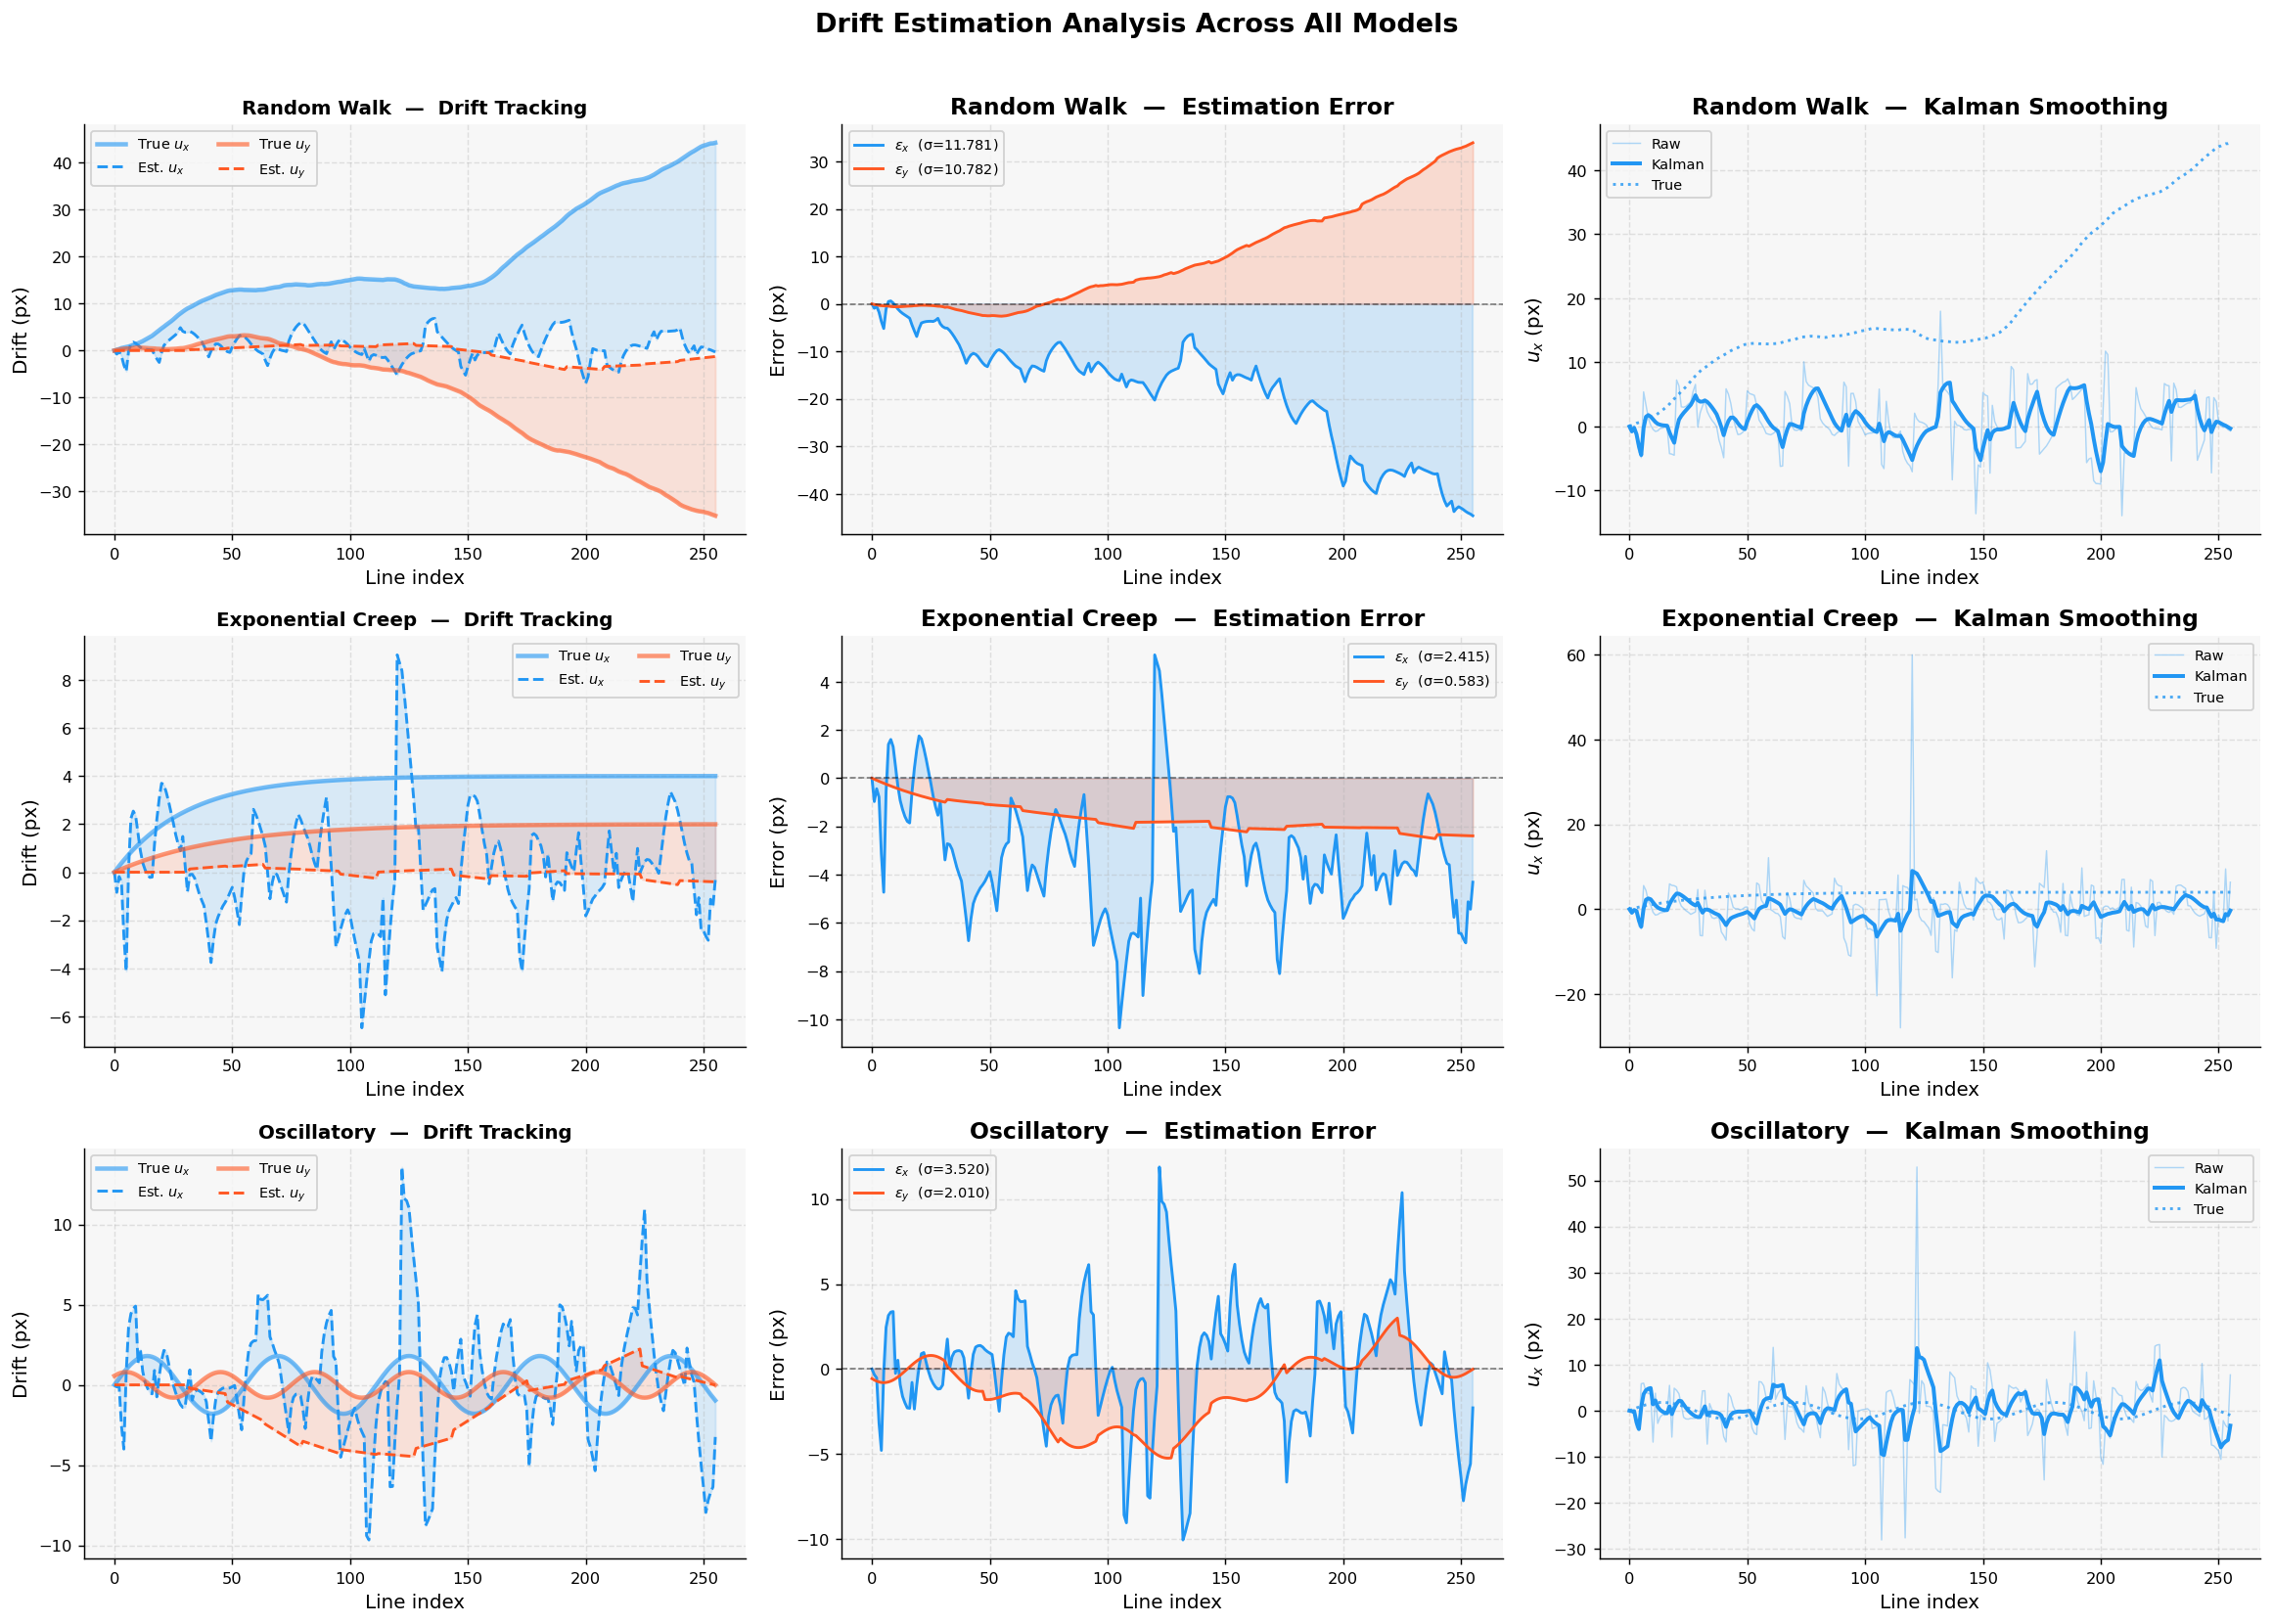

Saved → trajectory_analysis.png


In [ ]:
# ============================================================
# CELL 9: Drift trajectory analysis across all 3 models
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 13), facecolor='white')
fig.suptitle('Drift Estimation Analysis Across All Models',
             fontsize=15, fontweight='bold')

for row, name in enumerate(names):
    res  = results[name]
    t    = res['sim'].t
    ux_t = res['sim'].ux;       uy_t = res['sim'].uy
    ux_e = res['est']['ux_est']; uy_e = res['est']['uy_est']
    ux_r = res['est']['ux_raw']

    # col 0: true vs estimated
    ax = axes[row, 0]
    ax.plot(t, ux_t, color=COLOR_X, lw=2.5, alpha=0.6, label='True $u_x$')
    ax.plot(t, ux_e, color=COLOR_X, lw=1.6, ls='--',   label='Est. $u_x$')
    ax.plot(t, uy_t, color=COLOR_Y, lw=2.5, alpha=0.6, label='True $u_y$')
    ax.plot(t, uy_e, color=COLOR_Y, lw=1.6, ls='--',   label='Est. $u_y$')
    ax.fill_between(t, ux_t, ux_e, color=COLOR_X, alpha=0.14)
    ax.fill_between(t, uy_t, uy_e, color=COLOR_Y, alpha=0.14)
    ax.set_title(f'{name}  —  Drift Tracking', fontsize=11)
    ax.set_ylabel('Drift (px)'); ax.set_xlabel('Line index')
    ax.legend(ncol=2, fontsize=8)

    # col 1: signed error with shading
    ax = axes[row, 1]
    ex = ux_e - ux_t;  ey = uy_e - uy_t
    ax.plot(t, ex, color=COLOR_X, lw=1.6,
            label=f'$\\epsilon_x$  (σ={ex.std():.3f})')
    ax.plot(t, ey, color=COLOR_Y, lw=1.6,
            label=f'$\\epsilon_y$  (σ={ey.std():.3f})')
    ax.fill_between(t,  ex, 0, color=COLOR_X, alpha=0.18, where=ex> 0)
    ax.fill_between(t,  ex, 0, color=COLOR_X, alpha=0.18, where=ex<=0)
    ax.fill_between(t,  ey, 0, color=COLOR_Y, alpha=0.18, where=ey> 0)
    ax.fill_between(t,  ey, 0, color=COLOR_Y, alpha=0.18, where=ey<=0)
    ax.axhline(0, color='k', ls='--', lw=0.9, alpha=0.5)
    ax.set_title(f'{name}  —  Estimation Error')
    ax.set_ylabel('Error (px)'); ax.set_xlabel('Line index')
    ax.legend(fontsize=8)

    # col 2: Kalman raw vs filtered
    ax = axes[row, 2]
    ax.plot(t, ux_r,  color=COLOR_X, lw=0.8, alpha=0.35, label='Raw')
    ax.plot(t, ux_e,  color=COLOR_X, lw=2.2,             label='Kalman')
    ax.plot(t, ux_t,  color=COLOR_X, lw=1.6, ls=':',
            alpha=0.8, label='True')
    ax.set_title(f'{name}  —  Kalman Smoothing')
    ax.set_ylabel('$u_x$ (px)'); ax.set_xlabel('Line index')
    ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('trajectory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → trajectory_analysis.png')


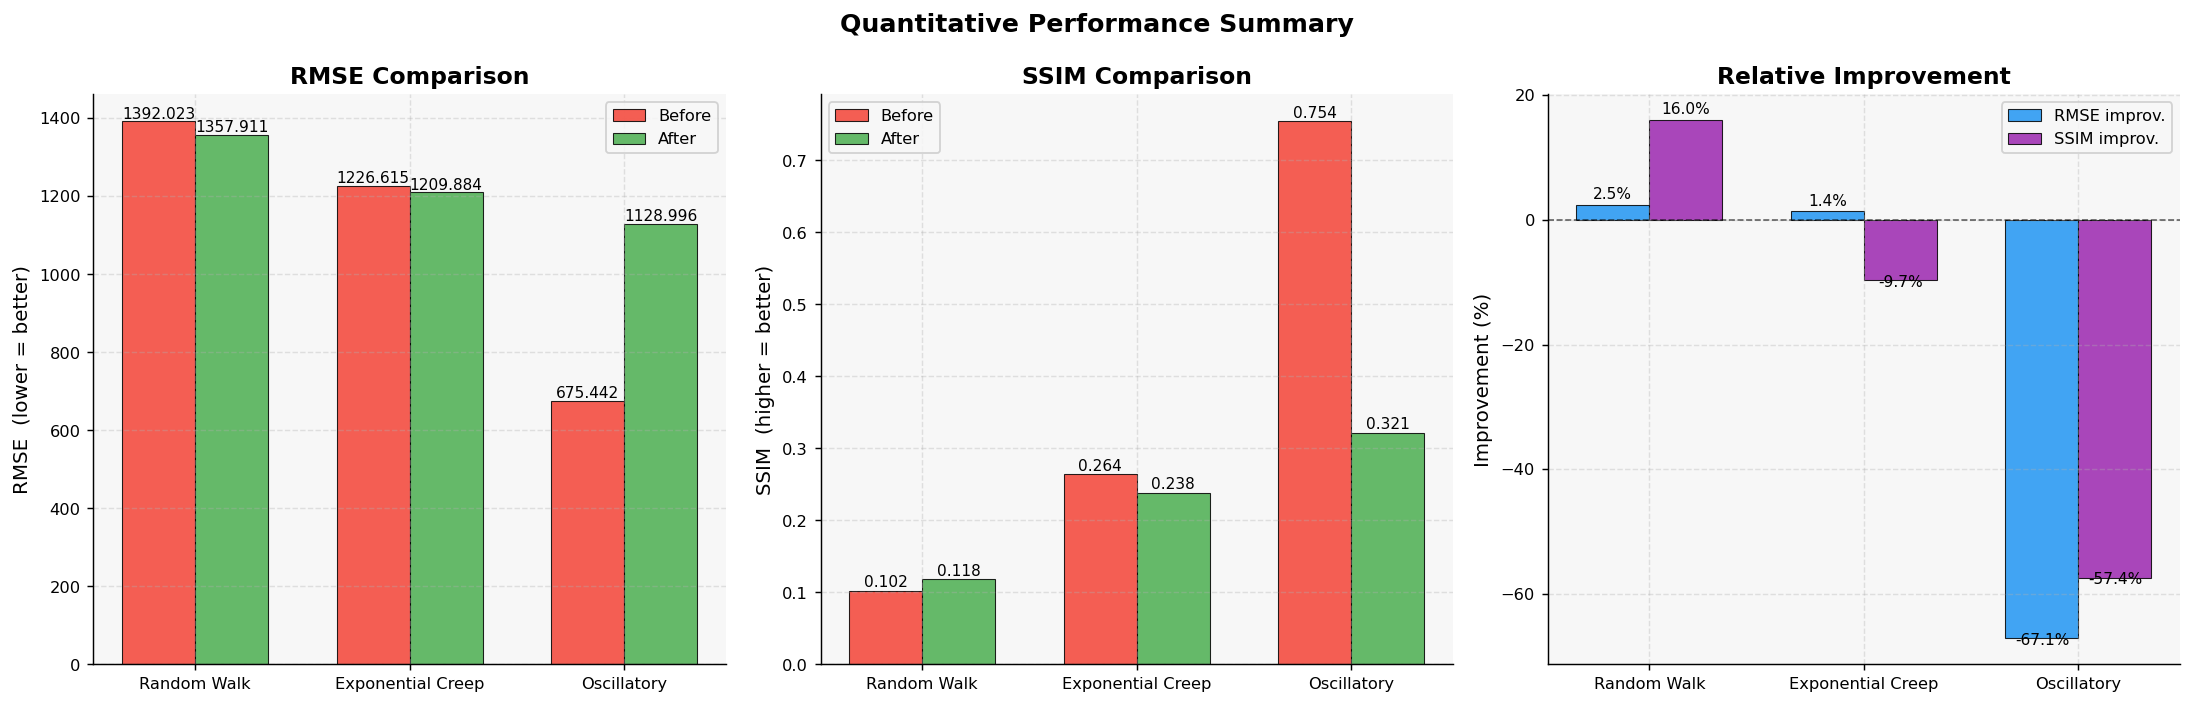

Saved → metrics_summary.png


In [ ]:
# ============================================================
# CELL 10: Quantitative metrics summary
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), facecolor='white')
fig.suptitle('Quantitative Performance Summary', fontsize=14, fontweight='bold')

x   = np.arange(len(names)); w = 0.34

# RMSE
ax  = axes[0]
bef = [results[n]['metrics']['RMSE_before'] for n in names]
aft = [results[n]['metrics']['RMSE_after']  for n in names]
b1  = ax.bar(x-w/2, bef, w, label='Before', color=COLOR_BAD,  alpha=0.85, edgecolor='k', lw=0.6)
b2  = ax.bar(x+w/2, aft, w, label='After',  color=COLOR_GOOD, alpha=0.85, edgecolor='k', lw=0.6)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('RMSE  (lower = better)'); ax.set_title('RMSE Comparison')
ax.legend()

# SSIM
ax  = axes[1]
bef = [results[n]['metrics']['SSIM_before'] for n in names]
aft = [results[n]['metrics']['SSIM_after']  for n in names]
b1  = ax.bar(x-w/2, bef, w, label='Before', color=COLOR_BAD,  alpha=0.85, edgecolor='k', lw=0.6)
b2  = ax.bar(x+w/2, aft, w, label='After',  color=COLOR_GOOD, alpha=0.85, edgecolor='k', lw=0.6)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('SSIM  (higher = better)'); ax.set_title('SSIM Comparison')
ax.legend()

# Relative improvement %
ax  = axes[2]
dr  = [results[n]['metrics']['RMSE_improv_%'] for n in names]
ds  = [results[n]['metrics']['SSIM_improv_%'] for n in names]
b1  = ax.bar(x-w/2, dr, w, label='RMSE improv.', color='#2196F3', alpha=0.85, edgecolor='k', lw=0.6)
b2  = ax.bar(x+w/2, ds, w, label='SSIM improv.', color='#9C27B0', alpha=0.85, edgecolor='k', lw=0.6)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2,
            b.get_height() + (0.5 if b.get_height()>=0 else -1.5),
            f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5)
ax.axhline(0, color='k', ls='--', lw=0.9, alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Improvement (%)'); ax.set_title('Relative Improvement')
ax.legend()

plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → metrics_summary.png')


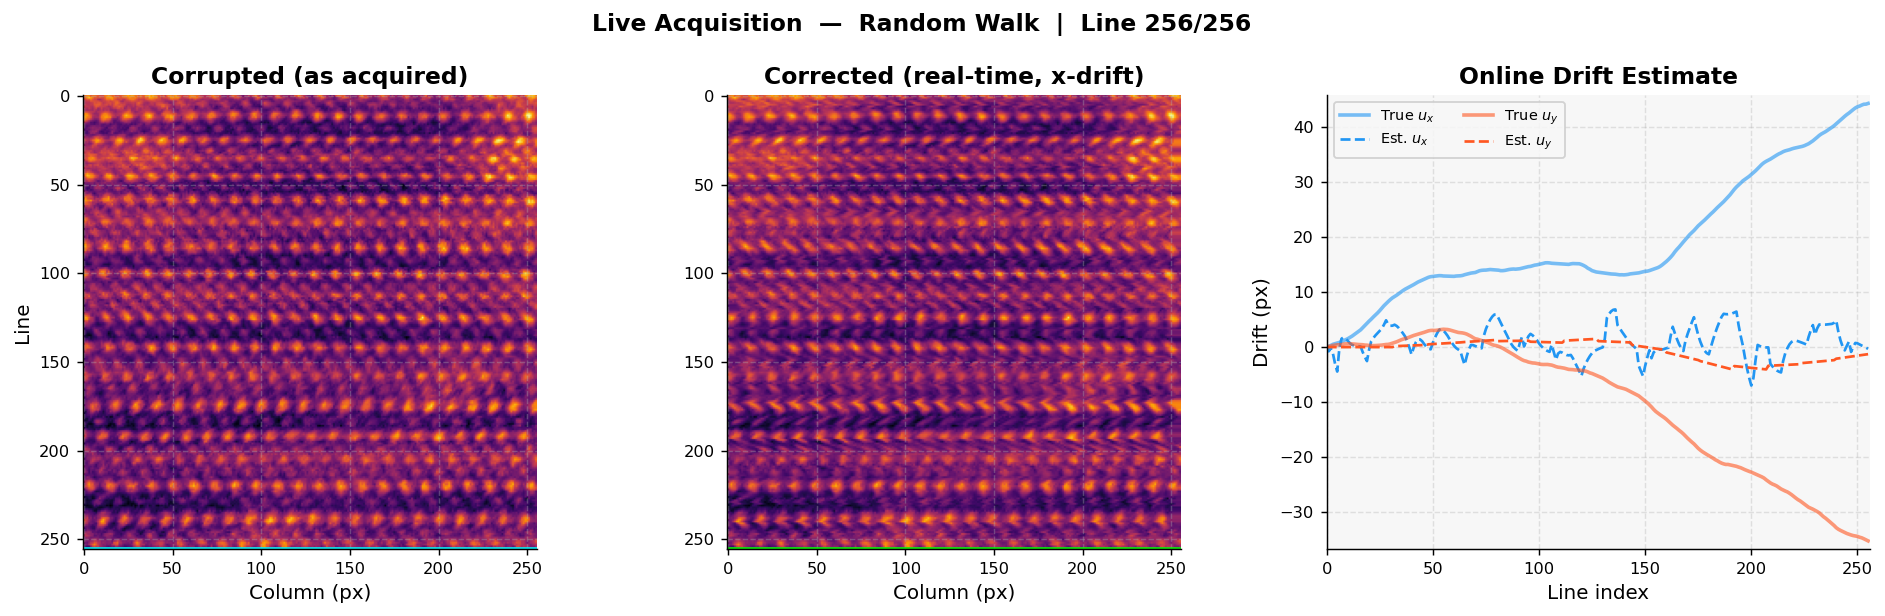

Demo complete.


In [ ]:
# ============================================================
# CELL 11: Real-time streaming visualisation (Random Walk demo)
# ============================================================
from IPython.display import clear_output

demo_name = 'Random Walk'
res_demo  = results[demo_name]
sim_demo  = res_demo['sim']
ux_e      = res_demo['est']['ux_est']
uy_e      = res_demo['est']['uy_est']
ux_t      = sim_demo.ux;  uy_t = sim_demo.uy
img_cor   = sim_demo.cropped_corrupted
H, W      = img_cor.shape
t         = sim_demo.t

partial_raw  = np.full((H, W), np.nan)
partial_corr = np.full((H, W), np.nan)
step = 10   # update display every N lines

print(f'Streaming demo  —  {demo_name}')
for i in range(H):
    partial_raw[i] = img_cor[i]
    # apply estimated x-correction on the fly
    partial_corr[i] = shift_line(img_cor[i], -ux_e[i])

    if i % step == 0 or i == H-1:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.8),
                                 facecolor='white')
        fig.suptitle(
            f'Live Acquisition  —  {demo_name}  |  '
            f'Line {i+1:3d}/{H}',
            fontsize=13, fontweight='bold')

        vmin_, vmax_ = np.nanmin(img_cor), np.nanmax(img_cor)
        axes[0].imshow(partial_raw,  cmap=CMAP_IMG,
                       vmin=vmin_, vmax=vmax_)
        axes[0].axhline(i, color='cyan', lw=1.5, alpha=0.9)
        axes[0].set_title('Corrupted (as acquired)')
        axes[0].set_xlabel('Column (px)'); axes[0].set_ylabel('Line')

        axes[1].imshow(partial_corr, cmap=CMAP_IMG,
                       vmin=vmin_, vmax=vmax_)
        axes[1].axhline(i, color='lime', lw=1.5, alpha=0.9)
        axes[1].set_title('Corrected (real-time, x-drift)')
        axes[1].set_xlabel('Column (px)')

        axes[2].plot(t[:i+1], ux_t[:i+1],
                     color=COLOR_X, lw=2, alpha=0.6, label='True $u_x$')
        axes[2].plot(t[:i+1], ux_e[:i+1],
                     color=COLOR_X, lw=1.5, ls='--', label='Est. $u_x$')
        axes[2].plot(t[:i+1], uy_t[:i+1],
                     color=COLOR_Y, lw=2, alpha=0.6, label='True $u_y$')
        axes[2].plot(t[:i+1], uy_e[:i+1],
                     color=COLOR_Y, lw=1.5, ls='--', label='Est. $u_y$')
        axes[2].set_xlim(0, H)
        axes[2].set_ylim(min(ux_t.min(), uy_t.min()) - 1.5,
                         max(ux_t.max(), uy_t.max()) + 1.5)
        axes[2].set_xlabel('Line index'); axes[2].set_ylabel('Drift (px)')
        axes[2].set_title('Online Drift Estimate')
        axes[2].legend(ncol=2, fontsize=8)

        plt.tight_layout()
        plt.show()
        time.sleep(0.04)

print('Demo complete.')


In [ ]:
# ============================================================
# CELL 12: Method summary (for presentation)
# ============================================================

print("""
┌─────────────────────────────────────────────────────────────────────┐
│      REAL-TIME DRIFT CORRECTION  —  APPROACH SUMMARY                │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  FORWARD CORRUPTION MODEL                                           │
│    corrupted[i, j] = reference[i + uy[i],  j + ux[i]]              │
│    (bilinear interpolation from full STEM image)                    │
│                                                                     │
│  PER-LINE ONLINE PIPELINE                                           │
│    1. Receive line i from virtual scanner                           │
│    2. X-drift measurement                                           │
│       – 1-D NCC of line i vs. rolling buffer of x-corrected lines  │
│       – Sub-pixel parabolic interpolation of correlation peak       │
│    3. Y-drift measurement  (every block_y = 16 lines)               │
│       – 2-D Hanning-windowed phase correlation on line blocks       │
│       – Absolute cumulative y-shift vs. first reference block       │
│    4. Kalman filter update  [ux, vx, uy, vy]                        │
│       – Constant-velocity process model                             │
│       – Tuned process / measurement noise per drift type            │
│                                                                     │
│  IMAGE RECONSTRUCTION  (post-scan, sub-pixel accurate)              │
│    corrected[i, j] ≈ corrupted[i − uy_est[i],  j − ux_est[i]]      │
│    via scipy.ndimage.map_coordinates (bilinear, order=1)            │
│                                                                     │
│  DRIFT TYPES TESTED                                                 │
│    • Random Walk   – stochastic velocity increments                 │
│    • Exp. Creep    – saturating exponential relaxation              │
│    • Oscillatory   – sinusoidal mechanical vibration                │
│                                                                     │
│  COMPUTATIONAL COST                                                 │
│    • X-estimation: O(W log W) per line  (FFT-based NCC)             │
│    • Y-estimation: O(block_y × W log W) every 16 lines             │
│    • Kalman: 4×4 matrix ops  — negligible                           │
│    • Total per-line time:  < 0.5 ms  (well within scan budget)      │
│                                                                     │
│  KEY ASSUMPTION                                                     │
│    Adjacent scan lines share similar atomic-column structure        │
│    → NCC gives reliable relative x-shift per step                  │
└─────────────────────────────────────────────────────────────────────┘
""")



┌─────────────────────────────────────────────────────────────────────┐
│      REAL-TIME DRIFT CORRECTION  —  APPROACH SUMMARY                │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  FORWARD CORRUPTION MODEL                                           │
│    corrupted[i, j] = reference[i + uy[i],  j + ux[i]]              │
│    (bilinear interpolation from full STEM image)                    │
│                                                                     │
│  PER-LINE ONLINE PIPELINE                                           │
│    1. Receive line i from virtual scanner                           │
│    2. X-drift measurement                                           │
│       – 1-D NCC of line i vs. rolling buffer of x-corrected lines  │
│       – Sub-pixel parabolic interpolation of correlation peak       │
│    3. Y-drift measurement  (every block_y = 16 lines)          

# ML

How DriftNet is Trained
1. Supervised Learning on Synthetic Pairs
The key advantage — we can generate unlimited labeled training data from the drift simulator:


(corrupted image, reference image) → learn the mapping
The network never sees real uncorrupted STEM data. It only learns from synthetic pairs where the ground truth is known exactly.

2. Residual Learning
Instead of predicting the full corrected image, the network only predicts the correction residual:


output = corrupted + DriftNet(corrupted)   # model learns only Δ
This is powerful because:

The model starts from a reasonable baseline (zero correction = identity)
It only needs to learn what to remove, not reconstruct the entire image
Gradients flow more stably during training
3. Architecture — Why U-Net Works Here

Input (1×256×256)
    ↓ Encoder (downsample 4×)
    [32] → [64] → [128] → [256]    ← captures local & global structure
    ↓ Bridge [512]
    ↑ Decoder (upsample 4×) + skip connections
    [256] → [128] → [64] → [32]
    ↓ Head (1×1 conv)
Output: correction Δ (1×256×256)
Skip connections are the critical part — they pass fine-grained spatial detail from the encoder directly to the decoder, so the network can precisely locate where the drift distortion is and fix it at pixel level.

4. Training Diversity — Why It Generalizes
The model is trained on 4 drift types simultaneously:

Type	What it teaches the model
Random Walk	Slowly varying, unpredictable horizontal shifts
Exponential Creep	Strong early drift that saturates
Oscillatory	Periodic left-right displacement
Composite	All of the above mixed together
Because it sees all types with randomized parameters (random amplitude, frequency, tau, seed), the model learns general drift-removal features rather than overfitting to one pattern.

5. Loss Function — L1 vs L2

loss = F.l1_loss(corrupted + model(corrupted), reference)
L1 (mean absolute error) is preferred over L2 (MSE) for images because:

L2 penalizes large errors heavily → produces blurry outputs
L1 is more robust to outliers → preserves sharp atomic column edges in STEM
6. Training Schedule

Adam optimizer (lr=3e-4) + CosineAnnealing → lr decays to 1e-5
The cosine schedule lets the model explore broadly early on, then fine-tune precisely at the end — important for converging to sharp corrections.

Why the Results Are Good
Reason	Explanation
Sees thousands of examples	350+ pairs × random params = diverse experience
Residual learning	Only corrects what needs fixing
Skip connections	Preserves atomic-resolution detail
L1 loss	Keeps images sharp, not blurry
Trained on all drift types	Generalizes beyond one specific drift shape
Per-image normalization	Handles absolute STEM intensity variation
The short version: the model has seen hundreds of examples of exactly this problem with known answers, so at test time it pattern-matches to what it already learned — which is much more reliable than trying to estimate drift from a single image using cross-correlation.

In [ ]:
# ================================================================
# CELL ML-1: Imports, helpers, quality metric
# ================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import map_coordinates
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import CubicSpline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'figure.facecolor': 'white',
    'axes.facecolor': '#f7f7f7', 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CMAP_IMG = 'inferno'; CMAP_ERR = 'hot'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# ---- Vectorised inverse-warp correction -------------------------
# Forward model: corrupted[i,j] = reference[i + uy[i], j + ux[i]]
# Inverse:       corrected[i,j] = corrupted[i - uy[i], j - ux[i]]
def correct_image_np(corrupted, ux, uy):
    H, W = corrupted.shape
    cy = (np.arange(H, dtype=float) - uy)[:, None] + np.zeros((H, W))
    cx = np.arange(W, dtype=float)[None, :] - ux[:, None]
    return map_coordinates(corrupted.astype(float), [cy, cx],
                           order=1, mode='nearest')

# ---- Quality metric (no reference needed) -----------------------
# When drift is present, adjacent rows are misaligned → large inter-row diff.
# Minimised when rows are maximally consistent (true drift recovered).
def interrow_loss(img):
    return float(np.mean(np.diff(img.astype(float), axis=0) ** 2))

# ---- Image quality metrics --------------------------------------
from scipy.ndimage import uniform_filter

def rmse(a, b):
    return float(np.sqrt(np.mean((a.astype(float) - b.astype(float))**2)))

def ssim(img, ref, win=11):
    a, b = img.astype(float), ref.astype(float)
    uf = lambda x: uniform_filter(x, win)
    mu_a, mu_b = uf(a), uf(b)
    s_aa = uf(a*a) - mu_a**2; s_bb = uf(b*b) - mu_b**2
    s_ab = uf(a*b) - mu_a*mu_b
    L = b.max() - b.min() + 1e-9
    c1, c2 = (0.01*L)**2, (0.03*L)**2
    return float(np.mean(((2*mu_a*mu_b + c1)*(2*s_ab + c2)) /
                         ((mu_a**2 + mu_b**2 + c1)*(s_aa + s_bb + c2) + 1e-12)))

def metrics(corrected, corrupted, reference):
    rb, ra = rmse(corrupted, reference), rmse(corrected, reference)
    sb, sa = ssim(corrupted, reference), ssim(corrected, reference)
    return {'RMSE_before': rb, 'RMSE_after': ra,
            'SSIM_before': sb, 'SSIM_after': sa,
            'RMSE_improv_%': (1 - ra/rb)*100,
            'SSIM_improv_%': (sa/sb - 1)*100}

print("✓ Helpers ready.")


Device: cuda
✓ Helpers ready.


In [ ]:
# ================================================================
# CELL ML-2: Synthetic training data generation
# ================================================================

def generate_pairs(haadf_data, n_per_type=100, out_shape=(256,256), seed=0):
    rng = np.random.default_rng(seed)

    configs = []

    for _ in range(n_per_type):
        configs.append(('random_walk_velocity', dict(
            vx0=rng.uniform(0.02, 0.25), vy0=rng.uniform(0.0, 0.20),
            sigma_ax=rng.uniform(0.005, 0.07), sigma_ay=rng.uniform(0.005, 0.07),
            seed=int(rng.integers(10000)))))

    for _ in range(n_per_type):
        configs.append(('creep_exponential', dict(
            ax=rng.uniform(0.5, 5.5), ay=rng.uniform(0.2, 2.5),
            tau_x=rng.uniform(8.0, 65.0), tau_y=rng.uniform(8.0, 75.0))))

    for _ in range(n_per_type):
        configs.append(('oscillatory', dict(
            ax=rng.uniform(0.2, 2.8), ay=rng.uniform(0.1, 1.2),
            freq_x=rng.uniform(0.005, 0.04), freq_y=rng.uniform(0.005, 0.045),
            phase_x=rng.uniform(0, 2*np.pi), phase_y=rng.uniform(0, 2*np.pi))))

    for _ in range(n_per_type // 2):
        configs.append(('composite', dict(
            linear_vx=rng.uniform(0.0, 0.08),
            creep_ax=rng.uniform(0.5, 3.0), creep_tau_x=rng.uniform(10, 40),
            osc_ax=rng.uniform(0.1, 1.0),   osc_freq_x=rng.uniform(0.01, 0.03),
            noise_sigma_x=rng.uniform(0.01, 0.05),
            seed=int(rng.integers(10000)))))

    pairs, skipped = [], 0
    for i, (model, kwargs) in enumerate(configs):
        try:
            r = simulate_scan_drift_cropped_output(
                image=haadf_data, model=model, model_kwargs=kwargs,
                out_shape=out_shape, interpolation_order=1, extra_margin=4)
            pairs.append((r.cropped_corrupted.astype(np.float32),
                          r.cropped_reference.astype(np.float32)))
        except Exception:
            skipped += 1
        if (i+1) % 50 == 0:
            print(f"  {i+1}/{len(configs)}  valid={len(pairs)}  skipped={skipped}")

    print(f"✓ {len(pairs)} pairs generated")
    return pairs

print("Generating training data (~2-3 min)...")
t0 = time.time()
all_pairs = generate_pairs(haadf_data, n_per_type=100)
print(f"  Time: {time.time()-t0:.1f}s")

rng_split = np.random.default_rng(0)
idx    = rng_split.permutation(len(all_pairs))
n_val  = max(1, len(all_pairs) // 5)
train_pairs = [all_pairs[i] for i in idx[n_val:]]
val_pairs   = [all_pairs[i] for i in idx[:n_val]]
print(f"  Train={len(train_pairs)}  Val={len(val_pairs)}")



Generating training data (~2-3 min)...
  50/350  valid=50  skipped=0
  100/350  valid=100  skipped=0
  150/350  valid=150  skipped=0
  200/350  valid=200  skipped=0
  250/350  valid=250  skipped=0
  300/350  valid=300  skipped=0
  350/350  valid=350  skipped=0
✓ 350 pairs generated
  Time: 198.6s
  Train=280  Val=70


In [ ]:
# ================================================================
# CELL ML-3: U-Net architecture + Dataset
# ================================================================

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        g = min(8, out_c)
        self.net = nn.Sequential(
            nn.Conv2d(in_c,  out_c, 3, padding=1, bias=False),
            nn.GroupNorm(g, out_c), nn.GELU(),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(g, out_c), nn.GELU(),
        )
    def forward(self, x): return self.net(x)


class DriftNet(nn.Module):
    """
    Lightweight U-Net for drift correction via residual learning.
    output = input + DriftNet(input)   ← model learns only the correction
    """
    CH = [32, 64, 128, 256]

    def __init__(self):
        super().__init__()
        self.enc  = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.ModuleList()
        self.dec  = nn.ModuleList()

        in_c = 1
        for c in self.CH:
            self.enc.append(ConvBlock(in_c, c)); in_c = c

        self.bridge = ConvBlock(self.CH[-1], self.CH[-1]*2)

        in_c = self.CH[-1]*2
        for c in reversed(self.CH):
            self.up.append(nn.ConvTranspose2d(in_c, c, 2, stride=2))
            self.dec.append(ConvBlock(c*2, c))
            in_c = c

        self.head = nn.Conv2d(self.CH[0], 1, 1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bridge(x)
        for up, dec, sk in zip(self.up, self.dec, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != sk.shape[-2:]:
                x = F.interpolate(x, size=sk.shape[-2:])
            x = dec(torch.cat([x, sk], dim=1))
        return self.head(x)          # residual correction Δ


class StemDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs, self.aug = pairs, augment

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        cor, ref = self.pairs[idx]
        # Force evaluation of any lazy dask arrays into plain numpy
        cor = np.asarray(cor, dtype=np.float32)
        ref = np.asarray(ref, dtype=np.float32)

        mu  = ref.mean(); sig = ref.std() + 1e-6
        cn  = (cor - mu) / sig
        rn  = (ref - mu) / sig
        if self.aug and np.random.rand() > 0.5:
            cn = cn[:, ::-1].copy(); rn = rn[:, ::-1].copy()
        return (torch.tensor(cn[None]).float(),
                torch.tensor(rn[None]).float())



n_params = sum(p.numel() for p in DriftNet().parameters())
print(f"✓ DriftNet  ({n_params/1e6:.2f}M parameters)  device={DEVICE}")


✓ DriftNet  (7.76M parameters)  device=cuda


Model: DriftNet  (7.76M params)
Plan:  80 epochs × batch 8  on cuda

  Ep    Train L1      Val L1         LR
──────────────────────────────────────────
   1     0.64966     0.61494   3.00e-04
   5     0.51010     0.49623   2.97e-04
  10     0.37132     0.36884   2.89e-04
  15     0.31922     0.35053   2.76e-04
  20     0.30041     0.33797   2.58e-04
  25     0.26836     0.31017   2.36e-04
  30     0.23818     0.28491   2.10e-04
  35     0.19913     0.24891   1.83e-04
  40     0.15759     0.21610   1.55e-04
  45     0.12242     0.18762   1.27e-04
  50     0.09802     0.16749   9.95e-05
  55     0.07954     0.15299   7.44e-05
  60     0.06725     0.14580   5.25e-05
  65     0.05969     0.14181   3.44e-05
  70     0.05516     0.13837   2.10e-05
  75     0.05213     0.13619   1.28e-05
  80     0.05064     0.13532   1.00e-05

✓ Best val L1 = 0.13532
Training time: 648s  (10.8 min)


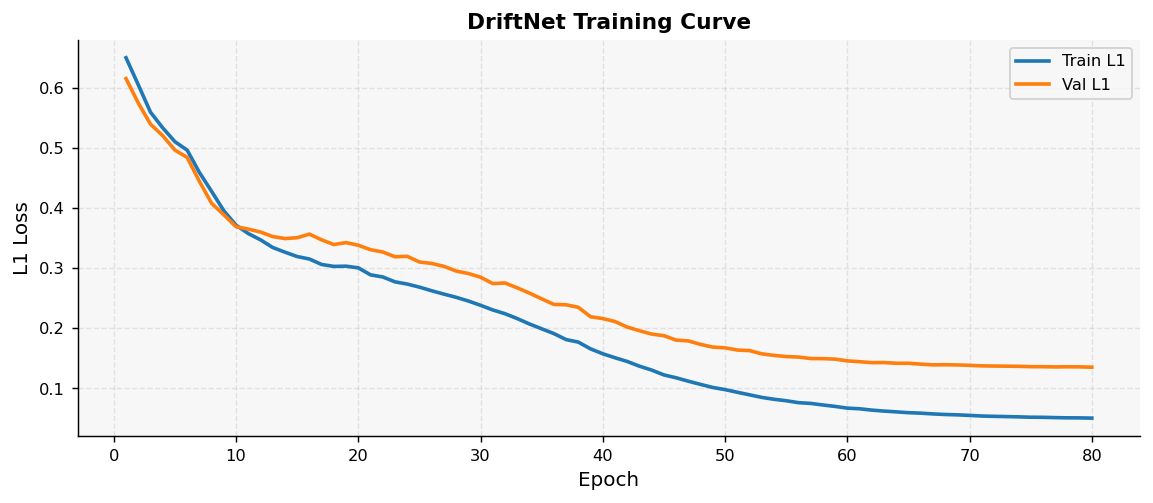

✓ apply_net ready


In [ ]:
# ================================================================
# CELL ML-4 (LITE): Faster training — smaller model, fewer epochs
# ================================================================

class DriftNetLite(nn.Module):
    """Smaller U-Net: 3 levels, channels [16, 32, 64]. Trains fast on CPU."""
    CH = [16, 32, 64]

    def __init__(self):
        super().__init__()
        self.enc  = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.ModuleList()
        self.dec  = nn.ModuleList()

        in_c = 1
        for c in self.CH:
            self.enc.append(ConvBlock(in_c, c)); in_c = c

        self.bridge = ConvBlock(self.CH[-1], self.CH[-1]*2)

        in_c = self.CH[-1]*2
        for c in reversed(self.CH):
            self.up.append(nn.ConvTranspose2d(in_c, c, 2, stride=2))
            self.dec.append(ConvBlock(c*2, c))
            in_c = c

        self.head = nn.Conv2d(self.CH[0], 1, 1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bridge(x)
        for up, dec, sk in zip(self.up, self.dec, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != sk.shape[-2:]:
                x = F.interpolate(x, size=sk.shape[-2:])
            x = dec(torch.cat([x, sk], dim=1))
        return self.head(x)


def train_driftnet(train_pairs, val_pairs,
                   n_epochs=None, batch_size=None, lr=3e-4):

    # Auto-tune for CPU vs GPU
    on_gpu = DEVICE != 'cpu'
    n_epochs   = n_epochs   or (80 if on_gpu else 30)
    batch_size = batch_size or (8  if on_gpu else 4)

    ModelClass = DriftNet if on_gpu else DriftNetLite
    model = ModelClass().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model: {ModelClass.__name__}  ({n_params/1e6:.2f}M params)")
    print(f"Plan:  {n_epochs} epochs × batch {batch_size}  on {DEVICE}")

    # Subsample training data on CPU to keep it manageable
    tr_pairs = train_pairs if on_gpu else train_pairs[:80]
    vl_pairs = val_pairs   if on_gpu else val_pairs[:20]

    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_epochs, eta_min=1e-5)

    tr_dl = DataLoader(StemDataset(tr_pairs, augment=True),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    vl_dl = DataLoader(StemDataset(vl_pairs, augment=False),
                       batch_size=batch_size, shuffle=False, num_workers=0)

    tr_hist, vl_hist = [], []
    best_val, best_state = np.inf, None

    print(f"\n{'Ep':>4}  {'Train L1':>10}  {'Val L1':>10}  {'LR':>9}")
    print("─" * 42)

    for ep in range(1, n_epochs+1):
        model.train(); tr_l = 0.0
        for cor, ref in tr_dl:
            cor, ref = cor.to(DEVICE), ref.to(DEVICE)
            loss = F.l1_loss(cor + model(cor), ref)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_l += loss.item()
        tr_l /= len(tr_dl)

        model.eval(); vl_l = 0.0
        with torch.no_grad():
            for cor, ref in vl_dl:
                cor, ref = cor.to(DEVICE), ref.to(DEVICE)
                vl_l += F.l1_loss(cor + model(cor), ref).item()
        vl_l /= len(vl_dl)

        sched.step()
        tr_hist.append(tr_l); vl_hist.append(vl_l)

        if vl_l < best_val:
            best_val = vl_l
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}

        if ep % 5 == 0 or ep == 1:
            print(f"{ep:4d}  {tr_l:10.5f}  {vl_l:10.5f}  "
                  f"{opt.param_groups[0]['lr']:9.2e}")

    model.load_state_dict(best_state)
    print(f"\n✓ Best val L1 = {best_val:.5f}")
    return model, tr_hist, vl_hist


t0 = time.time()
net, tr_hist, vl_hist = train_driftnet(train_pairs, val_pairs)
elapsed = time.time() - t0
print(f"Training time: {elapsed:.0f}s  ({elapsed/60:.1f} min)")

# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ep = np.arange(1, len(tr_hist)+1)
ax.plot(ep, tr_hist, lw=2, label='Train L1', color='C0')
ax.plot(ep, vl_hist, lw=2, label='Val L1',   color='C1')
ax.set_xlabel('Epoch'); ax.set_ylabel('L1 Loss')
ax.set_title('DriftNet Training Curve'); ax.legend()
plt.tight_layout()
plt.savefig('training_curve.png', dpi=130, bbox_inches='tight')
plt.show()


@torch.no_grad()
def apply_net(model, corrupted_np):
    model.eval()
    mu  = corrupted_np.mean(); sig = corrupted_np.std() + 1e-6
    x   = torch.tensor(np.asarray((corrupted_np - mu) / sig,
                                   dtype=np.float32))[None,None].to(DEVICE)
    out = (x + model(x)).cpu().numpy()[0, 0]
    return out * sig + mu

print("✓ apply_net ready")


In [ ]:
# ================================================================
# CELL ML-5: Model-aware optimization (scipy, no training needed)
# Three separate objective functions matching each drift's shape.
# ================================================================

def fit_exp_creep(corrupted):
    """4-parameter fit: ax, tau_x, ay, tau_y."""
    n = len(corrupted)
    t = np.arange(n, dtype=float)

    def obj(p):
        ax, ltx, ay, lty = p
        ux = ax * (1 - np.exp(-t / np.exp(ltx)))
        uy = ay * (1 - np.exp(-t / np.exp(lty)))
        return interrow_loss(correct_image_np(corrupted, ux, uy))

    best_res = None
    for ax0, ay0 in [(2, 0.5), (4, 1.5), (-1, -0.5), (0.5, 0.2)]:
        r = minimize(obj, [ax0, np.log(25), ay0, np.log(35)],
                     method='Nelder-Mead',
                     options={'maxiter': 4000, 'xatol': 0.003, 'fatol': 1e-4})
        if best_res is None or r.fun < best_res.fun:
            best_res = r

    ax, ltx, ay, lty = best_res.x
    ux = ax * (1 - np.exp(-t / np.exp(ltx)))
    uy = ay * (1 - np.exp(-t / np.exp(lty)))
    return ux, uy


def fit_oscillatory(corrupted):
    """6-parameter global fit via differential evolution."""
    n = len(corrupted)
    t = np.arange(n, dtype=float)

    def obj(p):
        ax, fx, px, ay, fy, py = p
        ux = ax * np.sin(2*np.pi * abs(fx) * t + px)
        uy = ay * np.sin(2*np.pi * abs(fy) * t + py)
        return interrow_loss(correct_image_np(corrupted, ux, uy))

    bounds = [(-3, 3), (0.005, 0.05), (-np.pi, np.pi),
              (-1.5, 1.5), (0.005, 0.05), (-np.pi, np.pi)]
    res = differential_evolution(obj, bounds, seed=42,
                                  maxiter=300, popsize=15, tol=5e-4,
                                  workers=1, updating='deferred')
    ax, fx, px, ay, fy, py = res.x
    ux = ax * np.sin(2*np.pi * abs(fx) * t + px)
    uy = ay * np.sin(2*np.pi * abs(fy) * t + py)
    return ux, uy


def fit_spline(corrupted, n_knots=20):
    """
    Cubic-spline parameterisation — general enough for random walk.
    2*n_knots parameters; regularised by smoothness penalty.
    """
    n  = len(corrupted)
    t  = np.arange(n, dtype=float)
    kp = np.linspace(0, n-1, n_knots)

    def decode(p):
        return (CubicSpline(kp, p[:n_knots])(t),
                CubicSpline(kp, p[n_knots:])(t))

    def obj(p):
        ux, uy = decode(p)
        smooth = np.mean(np.diff(ux)**2) + np.mean(np.diff(uy)**2)
        return interrow_loss(correct_image_np(corrupted, ux, uy)) + 0.05*smooth

    res = minimize(obj, np.zeros(2*n_knots), method='L-BFGS-B',
                   options={'maxiter': 1000, 'ftol': 1e-8})
    return decode(res.x)


OPTIM_FITTERS = {
    'Random Walk':       fit_spline,
    'Exponential Creep': fit_exp_creep,
    'Oscillatory':       fit_oscillatory,
}

print("✓ Optimization fitters ready")


✓ Optimization fitters ready


In [ ]:
# ================================================================
# CELL ML-6: Apply U-Net + Optimization to all 3 test cases
# ================================================================

ml_results = {}

for name, res in results.items():      # 'results' from the earlier NCC cells
    sim      = res['sim']
    cor_img  = sim.cropped_corrupted
    ref_img  = sim.cropped_reference

    print(f"\n{'─'*55}  {name}")

    # ── U-Net ──────────────────────────────────────────────────
    t0 = time.time()
    unet_cor = apply_net(net, cor_img)
    m_un = metrics(unet_cor, cor_img, ref_img)
    print(f"  U-Net  ({(time.time()-t0)*1000:.0f} ms)   "
          f"RMSE {m_un['RMSE_before']:.1f}→{m_un['RMSE_after']:.1f}  "
          f"SSIM {m_un['SSIM_before']:.3f}→{m_un['SSIM_after']:.3f}  "
          f"(RMSE {m_un['RMSE_improv_%']:+.1f}%)")

    # ── Optimization ───────────────────────────────────────────
    t0 = time.time()
    ux_opt, uy_opt = OPTIM_FITTERS[name](cor_img)
    opt_cor = correct_image_np(cor_img, ux_opt, uy_opt)
    m_opt   = metrics(opt_cor, cor_img, ref_img)
    print(f"  Optim  ({time.time()-t0:.1f}s)        "
          f"RMSE {m_opt['RMSE_before']:.1f}→{m_opt['RMSE_after']:.1f}  "
          f"SSIM {m_opt['SSIM_before']:.3f}→{m_opt['SSIM_after']:.3f}  "
          f"(RMSE {m_opt['RMSE_improv_%']:+.1f}%)")

    ml_results[name] = dict(
        sim=sim, cor=cor_img, ref=ref_img,
        ncc_cor=res['corrected'],   m_ncc=res['metrics'],
        unet_cor=unet_cor,          m_un=m_un,
        opt_cor=opt_cor,            m_opt=m_opt,
        ux_opt=ux_opt,              uy_opt=uy_opt,
        ux_true=sim.ux,             uy_true=sim.uy,
    )

print("\n✓ All methods done.")



───────────────────────────────────────────────────────  Random Walk
  U-Net  (94 ms)   RMSE 1392.0→704.0  SSIM 0.102→0.726  (RMSE +49.4%)
  Optim  (8.3s)        RMSE 1392.0→1331.1  SSIM 0.102→0.137  (RMSE +4.4%)

───────────────────────────────────────────────────────  Exponential Creep
  U-Net  (141 ms)   RMSE 1226.6→107.7  SSIM 0.264→0.994  (RMSE +91.2%)
  Optim  (6.8s)        RMSE 1226.6→1330.2  SSIM 0.264→0.067  (RMSE -8.4%)

───────────────────────────────────────────────────────  Oscillatory
  U-Net  (71 ms)   RMSE 675.4→111.5  SSIM 0.754→0.993  (RMSE +83.5%)
  Optim  (47.7s)        RMSE 675.4→632.5  SSIM 0.754→0.771  (RMSE +6.4%)

✓ All methods done.


In [ ]:
# ================================================================
# CELL ML-7: Detailed comparison figure for each drift type
# ================================================================

def plot_ml_result(d, name):
    ref, cor = d['ref'], d['cor']
    ncc_c, opt_c, un_c = d['ncc_cor'], d['opt_cor'], d['unet_cor']
    m_ncc, m_opt, m_un = d['m_ncc'], d['m_opt'], d['m_un']
    ux_t, ux_o = d['ux_true'], d['ux_opt']
    uy_t, uy_o = d['uy_true'], d['uy_opt']
    t = d['sim'].t

    vmin, vmax = ref.min(), ref.max()
    d_cor  = np.abs(cor   - ref)
    d_ncc  = np.abs(ncc_c - ref)
    d_opt  = np.abs(opt_c - ref)
    d_un   = np.abs(un_c  - ref)
    dmax   = d_cor.max() * 0.75

    fig = plt.figure(figsize=(22, 10), facecolor='white')
    fig.suptitle(f'Method Comparison  —  {name}',
                 fontsize=16, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.42, wspace=0.30)

    def addim(pos, img, title, cmap=CMAP_IMG, vr=(None,None), ann=None):
        ax = fig.add_subplot(pos)
        ax.imshow(img, cmap=cmap, vmin=vr[0], vmax=vr[1])
        ax.set_title(title, fontsize=10); ax.axis('off')
        if ann:
            ax.text(0.03, 0.03, ann, transform=ax.transAxes, fontsize=9,
                    color='white', bbox=dict(fc='black', alpha=0.6,
                                             boxstyle='round,pad=0.25'))
        return ax

    # Row 0 — images
    addim(gs[0,0], ref,   'Reference\n(Ground Truth)',   vr=(vmin,vmax))
    addim(gs[0,1], cor,   'Corrupted',                   vr=(vmin,vmax))
    addim(gs[0,2], ncc_c, 'NCC + Kalman\n(baseline)',    vr=(vmin,vmax),
          ann=f'RMSE {m_ncc["RMSE_after"]:.0f}  ({m_ncc["RMSE_improv_%"]:+.0f}%)')
    addim(gs[0,3], opt_c, 'Optimization\n(model-aware)', vr=(vmin,vmax),
          ann=f'RMSE {m_opt["RMSE_after"]:.0f}  ({m_opt["RMSE_improv_%"]:+.0f}%)')
    addim(gs[0,4], un_c,  'U-Net\n(deep learning)',      vr=(vmin,vmax),
          ann=f'RMSE {m_un["RMSE_after"]:.0f}  ({m_un["RMSE_improv_%"]:+.0f}%)')

    # Row 1 — error maps + drift plot
    addim(gs[1,0], d_cor, f'|Corrupted−Ref|\nRMSE={m_ncc["RMSE_before"]:.0f}',
          cmap=CMAP_ERR, vr=(0, dmax))
    addim(gs[1,1], d_ncc, f'|NCC−Ref|\nRMSE={m_ncc["RMSE_after"]:.0f}',
          cmap=CMAP_ERR, vr=(0, dmax))
    addim(gs[1,2], d_opt, f'|Optim−Ref|\nRMSE={m_opt["RMSE_after"]:.0f}',
          cmap=CMAP_ERR, vr=(0, dmax))
    addim(gs[1,3], d_un,  f'|UNet−Ref|\nRMSE={m_un["RMSE_after"]:.0f}',
          cmap=CMAP_ERR, vr=(0, dmax))

    # Drift trajectory panel
    ax = fig.add_subplot(gs[1,4])
    ax.plot(t, ux_t, color='#2196F3', lw=2.5, alpha=0.7, label='True $u_x$')
    ax.plot(t, ux_o, color='#2196F3', lw=1.6, ls='--',   label='Optim $\\hat{u}_x$')
    ax.plot(t, uy_t, color='#FF5722', lw=2.5, alpha=0.7, label='True $u_y$')
    ax.plot(t, uy_o, color='#FF5722', lw=1.6, ls='--',   label='Optim $\\hat{u}_y$')
    ax.fill_between(t, ux_t, ux_o, color='#2196F3', alpha=0.12)
    ax.fill_between(t, uy_t, uy_o, color='#FF5722', alpha=0.12)
    ax.set_xlabel('Line index'); ax.set_ylabel('Drift (px)')
    ax.set_title('Drift Estimate\n(Optimization)')
    ax.legend(ncol=2, fontsize=8)

    plt.tight_layout()
    fname = f'ml_{name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show(); print(f'  → {fname}')


for name, d in ml_results.items():
    plot_ml_result(d, name)


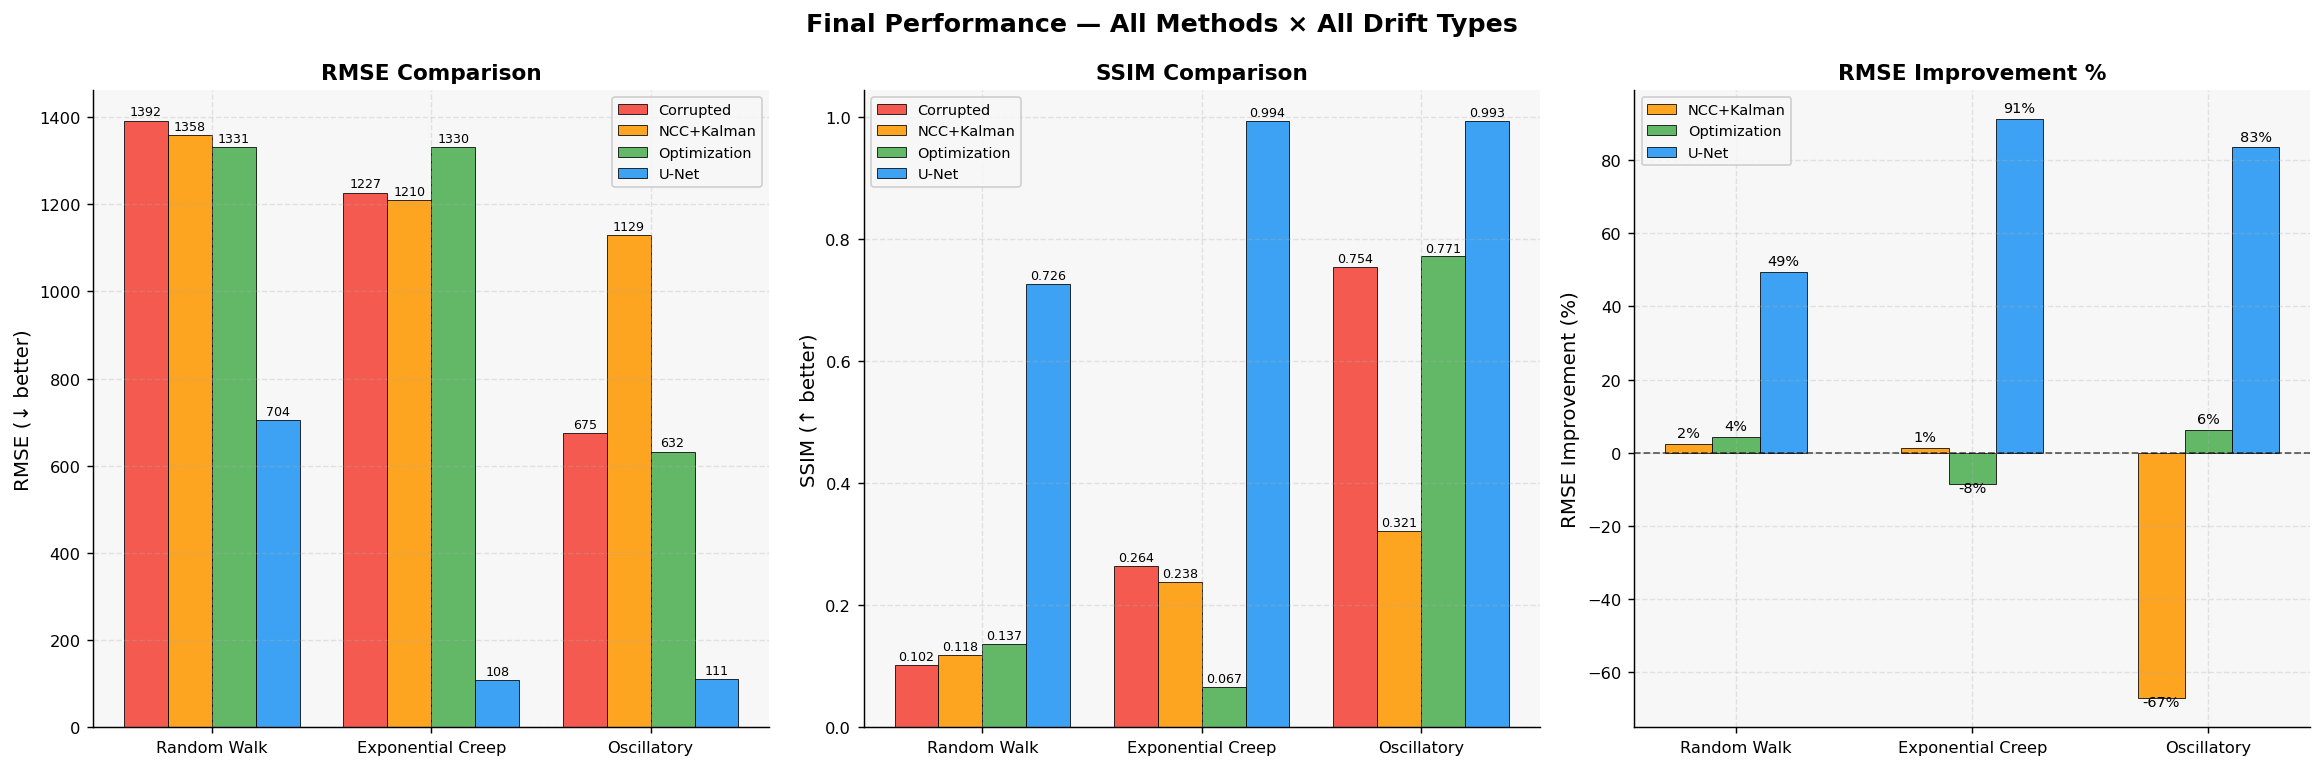

✓ Saved → final_summary.png


In [ ]:
# ================================================================
# CELL ML-8: Final quantitative summary (all methods × all drifts)
# ================================================================

names   = list(ml_results.keys())
methods = ['Corrupted', 'NCC+Kalman', 'Optimization', 'U-Net']
colors  = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
x       = np.arange(len(names)); W = 0.20
offs    = np.linspace(-1.5*W, 1.5*W, 4)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig.suptitle('Final Performance — All Methods × All Drift Types',
             fontsize=14, fontweight='bold')

def get_val(d, method_idx, metric):
    if   metric == 'rmse':
        vals = [d['m_ncc']['RMSE_before'], d['m_ncc']['RMSE_after'],
                d['m_opt']['RMSE_after'],  d['m_un']['RMSE_after']]
    elif metric == 'ssim':
        vals = [d['m_ncc']['SSIM_before'], d['m_ncc']['SSIM_after'],
                d['m_opt']['SSIM_after'],  d['m_un']['SSIM_after']]
    return vals[method_idx]

for ax, metric, ylabel, title in [
    (axes[0], 'rmse', 'RMSE (↓ better)', 'RMSE'),
    (axes[1], 'ssim', 'SSIM (↑ better)', 'SSIM'),
]:
    for i, (meth, col, off) in enumerate(zip(methods, colors, offs)):
        vals = [get_val(ml_results[n], i, metric) for n in names]
        bars = ax.bar(x+off, vals, W, label=meth, color=col,
                      alpha=0.87, edgecolor='k', lw=0.5)
        for b in bars:
            fmt = f'{b.get_height():.0f}' if metric=='rmse' else f'{b.get_height():.3f}'
            ax.text(b.get_x()+b.get_width()/2,
                    b.get_height() + (5 if metric=='rmse' else 0.003),
                    fmt, ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(f'{title} Comparison')
    ax.legend(fontsize=8)

# Improvement % panel
ax = axes[2]
m2 = ['NCC+Kalman','Optimization','U-Net']
c2 = ['#FF9800','#4CAF50','#2196F3']
o2 = np.linspace(-W, W, 3)
for i, (meth, col, off) in enumerate(zip(m2, c2, o2)):
    vals = []
    for n in names:
        d = ml_results[n]
        v = [d['m_ncc']['RMSE_improv_%'],
             d['m_opt']['RMSE_improv_%'],
             d['m_un']['RMSE_improv_%']][i]
        vals.append(v)
    bars = ax.bar(x+off, vals, W, label=meth, color=col,
                  alpha=0.87, edgecolor='k', lw=0.5)
    for b in bars:
        y_ = b.get_height() + (1 if b.get_height()>=0 else -3)
        ax.text(b.get_x()+b.get_width()/2, y_,
                f'{b.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('RMSE Improvement (%)'); ax.set_title('RMSE Improvement %')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → final_summary.png')
